# Deepdive 5: Comparative Analysis and Ablation Study of Neural Machine Translation (NMT) Architectures

### TABLE OF CONTENTS

1. [**Introduction**](#introduction)
2. [**Model Training**](#model-training)
3. [**Analysis**](#analysis)
4. [**Ablation Study**](#ablation-study)
5. [**Conclusion**](#conclusion)

## 1. Introduction 


### 1.1. Machine Translation in NLP

Machine Translation (MT) is a sub-field of Natural Language Processing (NLP) focused on the automated task of converting text from a source language to a target language while preserving semantic meaning. In modern NLP, this is primarily achieved through **Neural Machine Translation (NMT)**, which utilizes deep learning models to learn a mapping between different linguistic representations in a high-dimensional continuous space. Unlike older rule-based systems, NMT models process entire sentences as units, capturing context and long-range dependencies.



### 1.2. Structural Challenges in Neural Machine Translation

Developing an effective translation model involves overcoming several inherent bottlenecks, particularly when using Recurrent Neural Networks (RNNs) and dealing with structurally distant language pairs like Korean and English.

**I. Limitations of RNN-based Architectures**

* **Variable Input/Output Lengths**: Unlike simple classification, translation requires mapping a source sequence of length $N$ to a target sequence of length $M$. Standard RNNs struggle to manage this "many-to-many" mapping without an Encoder-Decoder structure.
* **The Vanishing Gradient Problem**: As the sequence length increases, the gradients used for training can diminish (vanish) as they are backpropagated through time. This makes it difficult for the model to remember and link information from the beginning of a long sentence to the end.
* **Information Bottleneck**: In a basic Seq2Seq model, the entire meaning of the source sentence must be compressed into a single fixed-length vector (the context vector). This "bottleneck" often leads to information loss for longer, more complex sentences.

**II. Linguistic and Structural Divergence**

* **Word Order (SOV vs. SVO)**: Korean follows a **Subject-Object-Verb (SOV)** structure, while English follows **Subject-Verb-Object (SVO)**. This requires the model to significantly reorder tokens, a task that demands a strong global understanding of the sentence.
* **Agglutinative vs. Analytic Nature**: Korean is an **agglutinative** language where particles (josa) and endings are attached to roots to indicate grammatical function. English is **analytic**, relying on word order and prepositions. This difference makes tokenization and alignment highly sensitive.
* **Spacing and Articles**: English utilizes articles (a, an, the) and strict spacing rules that do not have direct one-to-one equivalents in Korean. A model must learn to "hallucinate" or omit these tokens appropriately based on context.

**III. Algorithmic Sensitivity**

* **Exposure Bias**: During training, the model is often fed the ground-truth previous token (**Teacher Forcing**). However, during inference, it must rely on its own previous (potentially incorrect) predictions, leading to an accumulation of errors that can cause the sentence to collapse into repetitive loops.
* **Preprocessing Sensitivity**: Because of the structural gap, the choice of subword segmentation (e.g., BPE or Morpheme-based) is critical. Poor segmentation can lead to the model failing to recognize the core semantic meaning of a word amidst various grammatical particles.


### 1.3. Evolution of Methodologies in NMT

The field of NMT has evolved by introducing specialized cell structures and mechanisms to overcome the inherent limitations of standard RNNs.

**I. The Seq2Seq Era (2014): RNN and the "Many-to-Many" Problem**

* **Methodology**: Introduced by Sutskever et al. (2014) and Cho et al. (2014), using an **Encoder-Decoder** framework to map variable-length sequences.
* **Limitation**: Standard RNNs suffered from **Vanishing Gradients**, where the signal from the beginning of a sentence would disappear before reaching the end, making long-distance translation impossible.

**II. Solving Vanishing Gradients (2014-2015): The LSTM and GRU Era**

* **The LSTM Solution**: **Long Short-Term Memory (LSTM)** introduced a "Cell State" and "Gating Mechanisms" (Input, Forget, Output gates).
* **How it Solved the Problem**: By using the **Forget Gate**, the model could decide which information to keep or discard, creating a "highway" for gradients to flow without vanishing. This allowed the model to maintain long-term dependencies.
* **The GRU Alternative**: The **Gated Recurrent Unit (GRU)**, which you used in **Exp_07**, simplified the LSTM by merging gates, offering similar performance with fewer parameters and faster training.

>**RNN vs. LSTM/GRU**
>* **RNN**: Suffers from $O(n)$ gradient decay; the model physically "forgets" the beginning of a sentence as the sequence length increases.
>* **LSTM/GRU**: Uses **Gated Logic** (Input, Forget, Output gates) to protect the gradient flow through a "cell state" highway.
>* **Comparison**: While LSTM/GRU enables learning of long-range linguistic patterns, it is still **bottlenecked** by the requirement to compress the entire source sentence into a single, fixed-length context vector before decoding.


**III. The Attention Revolution (2015): Bahdanau Attention**

* **Methodology**: Introduced by Bahdanau et al. (2015), this added an **Attention mechanism** that allows the decoder to "look back" at specific parts of the source sentence at each step.
* **Impact**: It solved the **Information Bottleneck** by providing the decoder with direct access to all encoder states, rather than relying solely on a single fixed-length context vector.

>**LSTM/GRU vs. Bahdanau Attention**
>* **LSTM/GRU (Fixed-Vector)**: Relies on the final hidden state of the encoder to represent the entire source meaning, which leads to significant information loss in long sentences.
>* **Bahdanau Attention**: Implements a **Dynamic Alignment** mechanism that calculates a unique context vector for *each* decoding step by attending to all encoder hidden states.
>* **Comparison**: Attention removes the **"Fixed-Vector Bottleneck"**; instead of forcing the model to remember everything at once, it allows the decoder to "look back" at specific keywords in the source as needed.

**IV. Bidirectional Context (2015-2016): Bi-RNNs**

* **Methodology**: Utilizing **Bidirectional RNNs** allowed the encoder to process the source sentence in both forward and backward directions.
* **Impact**: This captured context from both sides of a word, which is critical for reordering **SOV (Korean)** to **SVO (English)** structures.

>**Unidirectional vs. Bidirectional RNN**
>* **Unidirectional**: Processes text only from left to right, meaning the representation of a word only contains information from the words that came before it.
>* **Bidirectional**: Processes the sequence in both **Forward and Backward** directions simultaneously.
>* **Comparison**: Bidirectional encoders capture **"Future Context"**; this is a critical upgrade for language pairs like **KO-EN** where the verb (at the end of a Korean sentence) dictates the structure of the English translation from the very beginning.

**V. The Transformer Paradigm (2017 - Present): Self-Attention**

* **Methodology**: Vaswani et al. (2017) introduced the **Transformer**, replacing recurrence entirely with **Self-Attention**.
* **Impact**: It eliminated the sequential nature of RNNs, allowing for massive parallelization and solving the vanishing gradient problem through direct "all-to-all" token connections.
>**RNN/Attention vs. Transformer**
>* **RNN/Attention (Sequential)**: Processes tokens one by one (step-by-step), making it slow and still susceptible to gradual signal loss over very long distances.
>* **Transformer**: Replaces recurrence entirely with **Self-Attention**, allowing every token in a sentence to interact with every other token regardless of distance.
>* **Comparison**: The Transformer eliminates the **"Sequential Processing Bottleneck"**; it achieves perfect parallelization and zero gradient decay across time steps, which is why it has replaced RNN-based models as the state-of-the-art (SOTA) in NLP.



##### **Evolution of Neural Machine Translation (NMT)**

| **Year** | **Architecture / Methodology** | **Key Innovation** | **Problem Solved** | **Impact & Limitations** |
| --- | --- | --- | --- | --- |
| **2014** | **Basic Seq2Seq** (Sutskever et al.) | **Encoder-Decoder** Framework | **Variable Input/Output Length**: Mapped $N$ source tokens to $M$ target tokens. | Enabled NMT to handle full sentences, but suffered from fixed-vector bottleneck. |
| **2014-2015** | **LSTM / GRU** (Gating Logic) | **Input, Forget, Output Gates** | **Vanishing Gradient**: Protected the gradient flow via cell state/gating. | Allowed learning of long-term dependencies; GRU (used in **Exp_07**) offered faster training. |
| **2015** | **Bahdanau Attention** | **Dynamic Alignment** | **Information Bottleneck**: The decoder can "look back" at all encoder states. | Revolutionized NMT performance on long sentences. **The core of your Experiment 07.** |
| **2015-2016** | **Bidirectional RNN** | **Forward & Backward** processing | **Contextual Blindness**: Captures information from both sides of a word. | Crucial for language pairs with different word orders (e.g., **KO-EN**). |
| **2017-** | **Transformer** (Vaswani et al.) | **Self-Attention** (No RNNs) | **Sequential Processing Bottleneck**: Direct token-to-token connections. | Current State-of-the-Art (SOTA). Perfect parallelization and zero gradient decay. |



**Technical Solutions**

* **Vanishing Gradient**: Solved initially by **LSTM/GRU**'s gating mechanism, and later completely bypassed by the **Transformer's** Self-Attention.
* **Word Order Divergence (SOV vs. SVO)**: Addressed by **Bidirectional Encoders** and **Attention mechanisms**, which allow the model to dynamically reorder tokens during decoding.
* **Information Bottleneck**: Solved by **Attention**, which removed the need to compress an entire sentence into a single fixed-length context vector.



### 1.4. Technical Implementation: Model Architecture

**I. Core Architectural Specifications**

The model is designed to handle the sequence-to-sequence mapping of Korean to English with the following hyperparameter configuration:

* **Seq2Seq + Bahdanau Attention**: Utilizes a dynamic alignment mechanism to resolve the information bottleneck inherent in fixed-length context vectors.
* **Unidirectional GRU**: Both the Encoder and Decoder utilize a single-direction Gated Recurrent Unit to balance computational efficiency with the ability to capture sequential dependencies.
* **Dimension Settings**:
* **Embedding Dimension (`EMB_DIM`)**: 256 units.
* **Hidden Dimension (`HID_DIM`)**: 512 units.


**II. Encoder Operations**

The Encoder's primary function is to compress the input Korean sequence into a series of hidden representations.

1. **Embedding Layer**: Maps input token indices into a 256-dimensional continuous vector space.
2. **Unidirectional GRU Layer**: Processes the embedded tokens sequentially from left to right.
* For each time step, it updates its internal hidden state based on the current input and the previous state.
* The final hidden state represents the summarized context of the entire input sentence, which is then passed to initialize the Decoder.


**III. Decoder Operations (Step-by-Step)**

The Decoder generates the target English sequence by selectively "attending" to different parts of the Encoder's outputs at each step.

1. **Attention Mechanism (Bahdanau)**:
* **Alignment Score**: The model compares the **previous decoder hidden state** with **all encoder hidden states**.
* **Context Vector**: A weighted sum of the encoder hidden states is calculated based on these scores, creating a context vector specifically tailored for the current word being generated.


2. **GRU Processing**:
* The input to the GRU is the **concatenation of the current word embedding and the context vector**.
* The GRU updates the decoder's hidden state ($HID\_DIM = 512$) using this combined information.


3. **Linear Projection Layer**:
* The GRU output, the context vector, and the embedding are concatenated and passed through a fully connected layer.
* This layer projects the combined features back into the vocabulary space (size 10,000) to determine the probability of the next token.




**IV. Training Strategy**

* **Teacher Forcing**: During the training phase, the model is fed the actual ground-truth token from the training set as the next input, rather than its own prediction.
  * Without Teacher Forcing: The model relies on its own potentially flawed predictions during training, leading to Exposure Bias.
  * With Teacher Forcing: The model is guided by the ground-truth "teacher" at every step, ensuring Stability and Faster Convergence.
* **Loss Function**: Cross-Entropy Loss is calculated by comparing the predicted probability distribution against the one-hot encoded target labels.




#### A. Understanding the Architecture

**1. Does GRU exist in both Encoder and Decoder?**

**Yes.** In a standard Seq2Seq model like the one used in your project, the GRU (Gated Recurrent Unit) is the "engine" for both parts, but they serve different purposes:

* **Encoder GRU**: Processes the input sequence to extract meaning and compress it into hidden states.
* **Decoder GRU**: Uses the context provided by the encoder and the previous word to predict the next word in the sequence.

**2. Understanding Dimensions: EMB_DIM vs. HID_DIM**

It is very common for `EMB_DIM` (256) and `HID_DIM` (512) to be different. They represent two different stages of data representation:

* **What is EMB_DIM (256)?**

    * **The "Dictionary" Phase**: This is the size of the vector used to represent a single word in isolation.
    * **Meaning**: Each word in your 10,000-word vocabulary is assigned a unique list of 256 numbers. This captures the **static meaning** of the word (e.g., "Apple" is a fruit).
    * **Usage**: It is used every time a word enters the model (at the start of the Encoder and at each step of the Decoder).

* **What is HID_DIM (512)?**

  * **The "Context" Phase**: This is the "brain capacity" of the GRU. It represents the **moving memory** of the sentence.
  * **Meaning**: As the model reads "The apple was eaten by...", the hidden state ($512$ numbers) updates to remember that "apple" is now the object of a sentence. It captures the **dynamically evolving context**.
  * **Why are they different?**: Processing context is much more complex than looking up a word's meaning. We give the hidden state more "room" (512) to store complicated grammatical relationships that a single word embedding (256) doesn't need to carry.
    * Capacity Logic: HID_DIM is typically larger than EMB_DIM (512 vs 256) because processing the complex relationships of a full sentence requires significantly more computational "room" than representing a single word.



**3. Does Hidden Dimension refer to the sum of Encoder and Decoder?**

This is a common point of confusion. Here is the breakdown:

* **Individual Capacity**: When you set `HID_DIM = 512`, it usually means **each** GRU layer has 512 units.
* **Layers vs. Units**:
  * **Units (512)**: Think of this as the number of "neurons" in one layer. It is **not** the number of layers. Your model likely has 1 layer with 512 neurons.
  * **Independence**: The Encoder has its own hidden state of 512, and the Decoder has its own hidden state of 512. They are the same size so that the Encoder's final thought can fit perfectly into the Decoder's initial memory.


**4. Is Embedding only valid at the beginning?**

**No.** While it is the "entry point," its influence persists:

* **Encoder**: It is the initial input. Without the embedding, the GRU has no data to process.
* **Decoder**: At **every single step** of the translation, the Decoder takes the embedding of the *previously predicted word* as input.
* **Final Output**: In your specific architecture, the embedding is often concatenated with the GRU output and the context vector right before the final prediction to remind the model what word it just said.



| Concept | Dimension | Purpose | Location |
| --- | --- | --- | --- |
| **Embedding** | 256 | Translates a word index into a numeric vector. | Input of Encoder & Every step of Decoder. |
| **Hidden State** | 512 | The "mental workspace" that holds the sentence context. | Inside the GRU of both Encoder & Decoder. |
| **Context Vector** | 512 | The result of the **Attention** mechanism. | Between Encoder and Decoder. |

**To summarize**
> 256 is how the model "reads" a word; 512 is how the model "thinks" about the whole sentence. They work together at every step to ensure the translation makes sense.



#### B. Layer-by-Layer Data Flow Analysis

To explain the data flow, let’s use a more complex example relevant to the news domain:
* **KO (Source):** "이탈리아 천문학자들이 행성의 대기에서 물을 발견했다."
* **EN (Target):** "Italian astronomers discovered water in the planet's atmosphere."

**I. The Encoder: Building the "Thought" Representation**

In an **Encoder GRU with 1-Layer (Unidirectional)**, the model processes the source sentence word by word.

* **Step 1: Embedding Layer**
  * **Input**: A tokenized Korean word (e.g., `천문학자들이`).
  * **Output**: A **256-D vector** representing the static meaning of "astronomers."


* **Step 2: GRU Layer**
  * **Input**:
    1. **Current Word Embedding** ($x_t$): The 256-D vector from Step 1.
    2. **Previous Hidden State** ($h_{t-1}$): A 512-D vector carrying context from "이탈리아."
  * **Output (Next Layer/Step)**:
    1. **New Hidden State** ($h_t$): An updated 512-D vector that now combines "이탈리아" + "천문학자들이."
    2. **Encoder Output**: This $h_t$ is saved to be used later by the Attention mechanism.




* **Final Step: Context Bridge**
  * **Input**: The final hidden state ($h_n$) after reading "발견했다."
  * **Output**: This **512-D vector** serves as the initial hidden state for the Decoder, representing the "summary" of the entire sentence.





**II. The Decoder: Generating the Translation**

The Decoder works iteratively. At each step, it must decide which English word to produce next by looking at the Encoder's outputs via **Bahdanau Attention**.

* **Step 1: Attention Layer (The "Focus" Step)**
  * **Input**: The **previous decoder hidden state** ($s_{t-1}$) and **all encoder hidden states** ($h_1 ... h_n$).
  * **Mechanism**: It calculates how much the current English word (e.g., "discovered") relates to each Korean word.
  * **Output**: A **512-D Context Vector**. For "discovered," this vector would have high weights on the encoder state for "발견했다."


* **Step 2: GRU Layer (The "Memory" Step)**
  * **Input**:
    1. **Context Vector**: 512-D (from Step 1).
    2. **Embedded Previous Word**: 256-D (e.g., the vector for "astronomers").


  * **Output**: A **new decoder hidden state** ($s_t$) of 512-D. This updates the model's memory that "astronomers" and "discovered" have already been processed.


* **Step 3: Fully Connected (FC) Layer (The "Prediction" Step)**
  * **Input**: A concatenation of the **current GRU output**, the **Context Vector**, and the **Embedded word**.
  * **Output**: A vector of size **10,000 (Vocabulary Size)**.
  * **Action**: A Softmax function is applied to these 10,000 values to pick the word with the highest probability (e.g., "water").




**Summary of Layer Connectivity**

| Component | Receives from... | Sends to... |
| --- | --- | --- |
| **Encoder Embedding** | Tokenizer (Word Index) | Encoder GRU |
| **Encoder GRU** | Embedding + Prev Hidden State | Next Step GRU + Attention Layer |
| **Attention Layer** | Prev Decoder State + All Encoder States | Decoder GRU (as Context Vector) |
| **Decoder GRU** | Context Vector + Prev Word Embedding | FC Layer + Next Step Decoder GRU |
| **FC Layer** | GRU Output + Context + Embedding | Final Output (Probability Dist.) |


#### C. Query (Q), Key (K), and Value (V) relationship
* **KO (Source):** "이탈리아(1) 천문학자들이(2) 행성의(3) 대기에서(4) 물을(5) 발견했다(6)."
* **EN (Target):** "Italian astronomers discovered water..."

**C.1. The QKV Breakdown: "Translating 'water'"**

In your example, let’s assume the Decoder has already generated "Italian astronomers discovered" and is now trying to generate the next word: **"water"**.

* **1. The Query (Q): The Decoder's Current Need**

  * **What it is:** The **Query** is the Hidden State of the Decoder ($s_{t-1}$).
  * **In your example:** Think of $s_{t-1}$ as a vector that encodes the thought: *"I have already said 'astronomers discovered,' and now I need a noun that acts as the object of 'discovered'."*
  * **Crucial Point:** $Q$ is **not** the word "water" itself. $Q$ is the **question** the Decoder is asking: *"Where in the Korean sentence is the object that was discovered?"*

* **2. The Keys (K): The Encoder's Search Index**
  * **What they are:** Every single hidden state from the Encoder ($h_1$ through $h_6$).\
  * **In your example:**
    * $h_1$: "I am information about 'Italy'."
    * $h_5$: "I am information about **'물을' (water + object marker)**."
    * $h_6$: "I am information about 'found/discovered'."
  * **The Comparison:** The Attention mechanism compares $Q$ (the question) against all $K$s (the index). It finds a **high similarity score** between the "need for an object" ($Q$) and the vector for "물을" ($h_5$).

* **3. The Values (V): The Raw Information Content**
  * **What they are:** In Bahdanau Attention, the **Values are identical to the Keys** ($h_1, ..., h_n$).
  * **In your example:** Once the model decides that $h_5$ (Key) is the most relevant, it takes the actual semantic information inside $h_5$ (Value) to build the **Context Vector**.
  * **Why are they the same?** Because in RNN-based attention, the hidden state $h_i$ acts as both the *label* (what word is this?) and the *content* (what does this word mean?).


**C.2. How the Context Vector is Built (The "Result")**

The **Context Vector** is a weighted sum of all **Values**. For the word "water," the math looks like this:

$$Context Vector = (0.01 \times V_{이탈리아}) + (0.02 \times V_{천문학자}) + ... + \mathbf{(0.85 \times V_{물을})} + ...$$

* **Input to Context Vector:** It takes bits of information from the entire Korean sentence, but it gives **85% of the weight** to the vector representing "물을."
* **The Misconception:** You asked if Key/Value is the "context + others." Actually, the **Context Vector** is the final result of combining all Values based on their Key-Query scores. It is the "refined answer" sent to the Decoder.


#### **Summary Comparison**

| Component | Role in your Example | Physical Identity |
| --- | --- | --- |
| **Query (Q)** | *"What was discovered?"* | Decoder Hidden State ($s_{t-1}$) |
| **Key (K)** | *"Check me! I am 'Italy', I am 'Water', I am 'Found'."* | Encoder Hidden States ($h_1 ... h_n$) |
| **Value (V)** | The actual semantic meaning of "물을" ($h_5$). | Encoder Hidden States ($h_1 ... h_n$) |
| **Result** | A single 512-D vector heavily weighted towards "물을". | **Context Vector** |

**C.3. Are K and V Always the Same for Every Decoder Step?**

The identity of Key (K) and Value (V) being the same is primarily a characteristic of RNN-based Seq2Seq Attention (like Bahdanau or Luong), rather than a universal rule for all attention mechanisms.

* **1. Static Source: The Encoder's "Memory Bank"**
  * The Keys (K) and Values (V) are derived directly from the **Encoder's Hidden States** ($h_1, h_2, ..., h_n$).

    * Once the Encoder finishes reading the Korean sentence ("이탈리아 천문학자들이..."), these hidden states are "frozen."
    * Whether the Decoder is generating the 1st word ("Italian") or the 5th word ("water"), it always looks back at the **exact same set of Encoder vectors**.
    * In this architecture, **Key = Value = Encoder Hidden States**.

* **2. Dynamic Selection: The "Weighting" is Different**
  * While the *source* (the pool of K and V) is the same, the **Resulting Context Vector** changes at every step because the **Query (Q)** changes.
    * **Step 3 (Target: "discovered")**:
      * **Q**: "What did the astronomers do?"
      * **K & V Pool**: {이탈리아, 천문학자들이, ..., 발견했다}
      * **Action**: High weight assigned to $V_{발견했다}$.


    * **Step 4 (Target: "water")**:
      * **Q**: "What was discovered?"
      * **K & V Pool**: {이탈리아, 천문학자들이, ..., 발견했다} (Same as above!)
      * **Action**: High weight assigned to $V_{물을}$.



* **3. Why are they the same in this model?**
  * In RNN-based Seq2Seq, we don't use separate linear projections to create distinct K and V vectors like we do in Transformers.

    * The **Hidden State ($h_i$)** is considered a "complete representation."
    * It contains both the **address/label** (to be matched by the Query) and the **content** (to be passed to the Decoder).
    * But the "book" (Context Vector) you take out of it depends on what you are currently looking for (Q).

  * **a. The Nature of RNN-based Attention (Bahdanau/Luong)**

    * Here, the "sameness" of K and V is a result of using **Hidden States** as the representation.

      * **The Hidden State is the "All-in-One":** In an RNN, a hidden state ($h_i$) is designed to be a complete summary of everything the model knows about a word at that position.
      * **No Transformation:** Unlike the Transformer, Bahdanau attention does not apply separate linear transformations (weights) to create distinct K and V vectors. It simply uses the raw $h_i$ to calculate the score (Key) and the exact same $h_i$ to build the context (Value).
      * **Protocol:** In this context, $K = V = \text{Encoder Hidden States}$.

  * **b. Bahdanau vs. Seq2Seq + "Any" Attention**
    * While most RNN-based attention models share this property, they differ in *how* they use the Query (Q):

      * **Bahdanau Attention (Additive):** Uses the **previous** decoder hidden state ($s_{t-1}$) as the Query. It calculates the score *before* the current GRU step.
      * **Luong Attention (Multiplicative):** Typically uses the **current** decoder hidden state ($s_t$) as the Query. It calculates the score *after* the GRU has processed the current word.
      * **Common Ground:** In both of these "classic" Seq2Seq attention types, K and V are almost always the same encoder hidden states.

  * **c. The Major Shift: The Transformer (Self-Attention)**

    * The reason you might be confused is that in modern **Transformer** architectures (post-2017), K and V are **NOT** the same.

      * **Linear Projections:** The Transformer takes an input and multiplies it by three *different* weight matrices ($W_Q, W_K, W_V$).
      * **Functional Split:** This creates three distinct vectors. Even if they start from the same word, the "Key" version of the word might focus on its grammar, while the "Value" version focuses on its meaning.

**Summary Table**

| Feature | Bahdanau / Seq2Seq RNN | Transformer (Self-Attention) |
| --- | --- | --- |
| **Source of K & V** | Encoder Hidden States ($h_1...h_n$) | Input Embeddings + Linear Projection |
| **Are K and V identical?** | **Yes** (Same vector used for both) | **No** (Distinct vectors via $W_K$ and $W_V$) |
| **Why?** | RNN states are fixed representations. | Projections allow for more specialized learning. |


#### D. Evolutionary Context: From RNN to Gated Units

In our study, we utilize the **Gated Recurrent Unit (GRU)** rather than a standard RNN to ensure stable training across long sequences. This section details the structural necessity of gated architectures.

**1. The Problem: The Vanishing Gradient**

Traditional Recurrent Neural Networks (RNNs) suffer from a fundamental mathematical flaw known as the **Vanishing Gradient problem**.

* As the model backpropagates error through many time steps, the gradient (the signal used to update weights) is repeatedly multiplied by the same weight matrices.
* If these weights are small, the gradient shrinks exponentially, effectively "vanishing" before it can reach the earlier parts of the sequence.
* **Result**: The model "forgets" the beginning of the sentence, making it impossible to translate long-range linguistic dependencies.

**2. The Solution: Gating Mechanisms**

To resolve this, **Long Short-Term Memory (LSTM)** and **Gated Recurrent Units (GRU)** were introduced. They act as a "conveyor belt" for information, allowing gradients to flow through time without being diminished by repeated multiplications.

**3. Comparative Analysis: LSTM vs. GRU**

While both architectures solve the vanishing gradient problem, we chose the **GRU** for **Experiment 07** due to its specific structural efficiencies.

| **Feature** | **LSTM (Long Short-Term Memory)** | **GRU (Gated Recurrent Unit)** |
| --- | --- | --- |
| **Gating Logic** | Uses 3 gates: **Input, Forget, and Output**. | Uses 2 gates: **Reset and Update**. |
| **State Management** | Maintains a separate **Cell State** ($c_t$) and **Hidden State** ($h_t$). | Merges Cell State and Hidden State into a single **Hidden State**. |
| **Complexity** | More parameters; computationally more expensive. | Fewer parameters; faster to train and more memory-efficient. |
| **Performance** | Better at capturing extremely complex, long-term patterns in massive datasets. | Often performs comparably to LSTM on smaller datasets with better generalization. |
| **K/V Identity** | **K=V** (Usually the Hidden State $h_t$). | **K=V** (The unified Hidden State $h_t$). |
| **Complexity** | More parameters; higher risk of overfitting on small data. | Fewer parameters; more efficient training. |

**The Only Difference: Cell State vs. Hidden State**

If we were to use an LSTM, there is one technical nuance regarding what constitutes the "Key" and "Value":
* **Hidden State ($h_t$)**: This is what is typically used as the **Key and Value**. It contains the filtered information that is passed to the next layer and the attention mechanism.
* **Cell State ($c_t$)**: This is the "internal memory" of the LSTM. In standard Seq2Seq, the cell state is **not** used as a Key or Value for the attention mechanism; it stays internal to the LSTM to solve the vanishing gradient problem.


## 2. Model Training

In [35]:
# ===========================================================================
# Global Imports & Configuration
# ===========================================================================
# 1. Essential Libraries 
import os, copy, time, glob, urllib.request
import numpy as np
import random
from tqdm import tqdm
import pandas as pd 
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
# from utils import * 
# from models import *
# from explainer import * 
# -------------------------------------------------------------------------
# STEP 1: Device Configuration (Optimized for Apple Silicon)
# -----------------------------------------------ㅊ--------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(">>> Using Apple Silicon (MPS) for acceleration.")
else:
    device = torch.device("cpu")
    print(">>> Using CPU.")

>>> Using Apple Silicon (MPS) for acceleration.


In [6]:
# -------------------------------------------------------------------------
# STEP 2: Dataset Download & Cleaning
# -----------------------------------------------ㅊ--------------------------
import re
import sentencepiece as spm

# Function to clean text (applied to all sets)
def clean_text(text, is_korean=True):
    if is_korean:
        # Keep Hangul, English, and basic punctuation
        return re.sub(r"[^ㄱ-ㅎ가-힣a-zA-Z?.!, ]+", " ", text).strip()
    else:
        # Lowercase + Keep English and basic punctuation
        return re.sub(r"[^a-zA-Z?.!, ]+", " ", text).lower().strip()

def load_and_preprocess(ko_path, en_path):
    with open(ko_path, 'r', encoding='utf-8') as f_ko, \
         open(en_path, 'r', encoding='utf-8') as f_en:
        ko_data = [clean_text(line) for line in f_ko]
        en_data = [clean_text(line, is_korean=False) for line in f_en]
    return ko_data, en_data

# Load all three sets
train_ko, train_en = load_and_preprocess('./data/korean-english-park.train.ko', './data/korean-english-park.train.en')
val_ko, val_en     = load_and_preprocess('./data/korean-english-park.dev.ko', './data/korean-english-park.dev.en')
test_ko, test_en   = load_and_preprocess('./data/korean-english-park.test.ko', './data/korean-english-park.test.en')

print(f"Data Loaded: Train({len(train_ko)}), Val({len(val_ko)}), Test({len(test_ko)})")

Data Loaded: Train(94123), Val(1000), Test(2000)


In [ ]:
# -------------------------------------------------------------------------
# STEP 3: Data Preprocessing: Tokenization 
# -------------------------------------------------------------------------
# Corpus Generation and SentencePiece Training
# -------------------------------------------------------------------------
# Save only train data for vocabulary building
with open("ko_corpus.txt", "w", encoding="utf-8") as f: f.write("\n".join(train_ko))
with open("en_corpus.txt", "w", encoding="utf-8") as f: f.write("\n".join(train_en))

# Train SPM (Vocab Size: 10,000)
vocab_size = 10000
spm.SentencePieceTrainer.train(
    input="ko_corpus.txt", model_prefix="encoder_spm", vocab_size=vocab_size,
    pad_id=0, bos_id=1, eos_id=2, unk_id=3, model_type="unigram"
)
spm.SentencePieceTrainer.train(
    input="en_corpus.txt", model_prefix="decoder_spm", vocab_size=vocab_size,
    pad_id=0, bos_id=1, eos_id=2, unk_id=3, model_type="unigram"
)

# Load Tokenizers
ko_tokenizer = spm.SentencePieceProcessor(model_file="encoder_spm.model")
en_tokenizer = spm.SentencePieceProcessor(model_file="decoder_spm.model")# Save only train data for vocabulary building
with open("ko_corpus.txt", "w", encoding="utf-8") as f: f.write("\n".join(train_ko))
with open("en_corpus.txt", "w", encoding="utf-8") as f: f.write("\n".join(train_en))

# Train SPM (Vocab Size: 10,000)
vocab_size = 10000
spm.SentencePieceTrainer.train(
    input="ko_corpus.txt", model_prefix="encoder_spm", vocab_size=vocab_size,
    pad_id=0, bos_id=1, eos_id=2, unk_id=3, model_type="unigram"
)
spm.SentencePieceTrainer.train(
    input="en_corpus.txt", model_prefix="decoder_spm", vocab_size=vocab_size,
    pad_id=0, bos_id=1, eos_id=2, unk_id=3, model_type="unigram"
)

# Load Tokenizers
ko_tokenizer = spm.SentencePieceProcessor(model_file="encoder_spm.model")
en_tokenizer = spm.SentencePieceProcessor(model_file="decoder_spm.model")

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ko_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 10000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [ ]:
# -------------------------------------------------------------------------
# STEP 4: Data Preprocessing: Tokenization 
# -------------------------------------------------------------------------
# Tokenization and Padding Logic in PyTorch
# -------------------------------------------------------------------------
import torch
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    """
    Custom Dataset for Korean-English Translation.
    Handles tokenization, BOS/EOS attachment, and padding.
    """
    def __init__(self, src_sentences, trg_sentences, src_tokenizer, trg_tokenizer, max_len):
        self.src_sentences = src_sentences
        self.trg_sentences = trg_sentences
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer
        self.max_len = max_len
        
        # Reserved IDs from SentencePiece
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        # 1. Encode text to IDs
        src_ids = self.src_tokenizer.encode_as_ids(self.src_sentences[idx])
        trg_ids = self.trg_tokenizer.encode_as_ids(self.trg_sentences[idx])

        # 2. Source Processing (Truncation)
        src_ids = src_ids[:self.max_len]

        # 3. Target Processing (Teacher Forcing split)
        # Input: [BOS, word1, word2, ...] 
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 1] 
        # Label: [word1, word2, ..., EOS]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 4. Manual Padding (Ensures fixed length for batching)
        src_padding = [self.pad_id] * (self.max_len - len(src_ids))
        src_ids += src_padding

        trg_input_padding = [self.pad_id] * (self.max_len - len(trg_input))
        trg_input += trg_input_padding

        trg_label_padding = [self.pad_id] * (self.max_len - len(trg_label))
        trg_label += trg_label_padding

        return (
            torch.tensor(src_ids, dtype=torch.long), 
            torch.tensor(trg_input, dtype=torch.long), 
            torch.tensor(trg_label, dtype=torch.long)
        )


In [ ]:
# -------------------------------------------------------------------------
# STEP 5: DataLoader Setup
# -------------------------------------------------------------------------
# --- Dataset and DataLoader Creation ---
max_len = 50
batch_size = 64
pad_id = 0 
train_dataset = TranslationDataset(train_ko, train_en, ko_tokenizer, en_tokenizer, max_len)
val_dataset   = TranslationDataset(val_ko, val_en, ko_tokenizer, en_tokenizer, max_len)
test_dataset  = TranslationDataset(test_ko, test_en, ko_tokenizer, en_tokenizer, max_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, num_workers=4)

print("DataLoaders are ready for training.")

# --- Data Verification ---
# Sanity check to confirm tensor shapes match the expected [Batch_Size, Max_Len]
# We are using max_len=50 for Korean-English pairs to capture full sentence context.

for src, trg_input, trg_label in train_loader:
    print(f"{'='*20} Shape Verification {'='*20}")
    print(f"Source Shape (Korean)  : {src.shape}")         # Expected: [64, 50]
    print(f"Target Input Shape (English): {trg_input.shape}") # Expected: [64, 50]
    print(f"Target Label Shape (English): {trg_label.shape}") # Expected: [64, 50]
    
    # Check if the BOS and EOS tokens are correctly placed in the first sample
    print(f"\n{'='*20} Content Check (Sample 0) {'='*20}")
    print(f"First 5 tokens of Source: {src[0][:5].tolist()}")
    print(f"First 5 tokens of Target Input (Should start with BOS=1): {trg_input[0][:5].tolist()}")
    print(f"First 5 tokens of Target Label: {trg_label[0][:5].tolist()}")
    break

DataLoaders are ready for training.
==================== Shape Verification ====================
Source Shape (Korean)  : torch.Size([64, 50])
Target Input Shape (English): torch.Size([64, 50])
Target Label Shape (English): torch.Size([64, 50])

==================== Content Check (Sample 0) ====================
First 5 tokens of Source: [262, 3910, 1407, 1348, 31]
First 5 tokens of Target Input (Should start with BOS=1): [1, 12, 40, 235, 47]
First 5 tokens of Target Label: [12, 40, 235, 47, 17]


### Model Architecture Design
This section defines the Neural Machine Translation (NMT) model using a Gated Recurrent Unit (GRU) backbone and a Bahdanau Attention mechanism.

In [ ]:
# -------------------------------------------------------------------------
# STEP 6: Model Architecture Design
# -------------------------------------------------------------------------
# 1. Bahdanau Attention Mechanism
# --------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    """
    Bahdanau Attention mechanism using a unified weight matrix 'W' 
    to align with the Exp_07 checkpoint state_dict.
    """
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        # Exp_07 was trained using a single linear layer for concatenated inputs.
        # Input size: (Encoder Hidden * 2 for Bidirectional) + Decoder Hidden.
        self.W = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: [batch_size, dec_hid_dim]
        # encoder_outputs: [src_len, batch_size, enc_hid_dim * 2]
        
        src_len = encoder_outputs.shape[0]
        
        # Tile the decoder hidden state to match the source sequence length.
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1) 
        encoder_outputs = encoder_outputs.permute(1, 0, 2) 

        # Calculate energy by passing concatenated states through the unified 'W' layer.
        # Energy result: [batch_size, src_len, dec_hid_dim]
        energy = torch.tanh(self.W(torch.cat((hidden, encoder_outputs), dim=2)))
        
        # Squeeze the final dimension to get a score for each source word.
        attention = self.v(energy).squeeze(2) 
        
        # Apply Softmax to generate the probability distribution (attention weights).
        return F.softmax(attention, dim=1)

In [ ]:
# -------------------------------------------------------------------------
# STEP 6: Model Architecture Design
# -------------------------------------------------------------------------
# 2. Encoder and Decoder Modules
# --------------------------------------------------------------------------
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout, bidirectional=True):
        super().__init__()
        # Checkpoint shows embedding size 512
        self.embedding = nn.Embedding(input_dim, emb_dim) 
        
        # Checkpoint requires bidirectional=True for 'reverse' weights
        self.rnn = nn.GRU(emb_dim, enc_hid_dim, bidirectional=bidirectional)
        
        # Checkpoint requires this FC layer to map [fwd; bwd] to decoder size
        self.fc = nn.Linear(enc_hid_dim * 2 if bidirectional else enc_hid_dim, dec_hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        
        if self.rnn.bidirectional:
            # Concatenate the final forward and backward hidden states
            hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        else:
            hidden = torch.tanh(self.fc(hidden[-1,:,:]))
            
        return outputs, hidden

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        
        # RNN input: [embedding; context_vector]
        # Context vector size is enc_hid_dim * 2 due to Bidirectional Encoder in Exp_07
        self.rnn = nn.GRU((enc_hid_dim * 2) + emb_dim, dec_hid_dim)
        
        # Final output layer projects combined features to vocabulary size
        self.fc_out = nn.Linear((enc_hid_dim * 2) + dec_hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input: [batch size]
        # hidden: [batch size, dec_hid_dim]
        # encoder_outputs: [src len, batch size, enc_hid_dim * 2]
        
        input = input.unsqueeze(0) # [1, batch size]
        embedded = self.dropout(self.embedding(input)) # [1, batch size, emb_dim]
        
        # Calculate attention weights (alignment)
        # a: [batch size, src len]
        a = self.attention(hidden, encoder_outputs)
        
        # Prepare for batch matrix multiplication
        a_unsqueezed = a.unsqueeze(1) # [batch size, 1, src len]
        encoder_outputs_permuted = encoder_outputs.permute(1, 0, 2) # [batch size, src len, enc_hid_dim * 2]
        
        # Compute the weighted context vector
        weighted = torch.bmm(a_unsqueezed, encoder_outputs_permuted) # [batch size, 1, enc_hid_dim * 2]
        weighted = weighted.permute(1, 0, 2) # [1, batch size, enc_hid_dim * 2]
        
        # Concatenate embedding and weighted context for RNN input
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        
        # Prepare tensors for final linear layer
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        
        # RETURN THREE VALUES: prediction, hidden state, and attention weights
        return prediction, hidden.squeeze(0), a

In [12]:
# -------------------------------------------------------------------------
# STEP 6: Model Architecture Design
# -------------------------------------------------------------------------
# 3. Seq2Seq System Integration
# --------------------------------------------------------------------------
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id=1, eos_id=2):
        batch_size = src.shape[1]
        outputs = []
        attentions = []

        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            # Training Mode (Teacher Forcing)
            for t in range(0, trg.shape[0]):
                output, hidden, attention = self.decoder(trg[t], hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            # Inference Mode (Greedy Decoding)
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                
                top1 = output.argmax(1)
                input = top1
                finished |= (top1 == eos_id)
                if finished.all(): break

        return torch.cat(outputs, dim=0), torch.cat(attentions, dim=0)

In [ ]:
# -------------------------------------------------------------------------
# STEP 7: Training Configuration & Hyperparameters
# -------------------------------------------------------------------------
import torch.optim as optim

# Comprehensive Hyperparameter Dictionary
HYPERS = {
    "MODEL_NAME": "Seq2Seq_Attention_v1",
    # Use the correct variable names defined in Step 4
    "INPUT_DIM": len(ko_tokenizer),       # Source (Korean) vocab size
    "OUTPUT_DIM": len(en_tokenizer),      # Target (English) vocab size
    "EMB_DIM": 256,                       
    "HID_DIM": 512,                       
    "LR": 1e-3,                           
    "BATCH_SIZE": 128,
    "EPOCHS": 20,
    "PATIENCE": 5,                        
    "START_EPOCH": 0,
    "WEIGHT_DECAY": 1e-5
}

# --- Model Initialization using HYPERS ---
# Ensure the classes Encoder, Decoder, BahdanauAttention are defined before this
encoder = Encoder(input_dim=HYPERS["INPUT_DIM"], 
                  emb_dim=HYPERS["EMB_DIM"], 
                  hidden_dim=HYPERS["HID_DIM"]).to(device)

attention = BahdanauAttention(hidden_dim=HYPERS["HID_DIM"]).to(device)

decoder = Decoder(output_dim=HYPERS["OUTPUT_DIM"], 
                  emb_dim=HYPERS["EMB_DIM"], 
                  hidden_dim=HYPERS["HID_DIM"], 
                  attention=attention).to(device)

# Instantiate the full Seq2Seq Model
model = Seq2SeqAttention(encoder, decoder, device).to(device)

# --- Optimization Setup ---
# criterion uses pad_id=0 (defined in Dataset step)
optimizer = optim.Adam(
    model.parameters(), 
    lr=HYPERS["LR"], 
    weight_decay=HYPERS["WEIGHT_DECAY"]
)
criterion = nn.CrossEntropyLoss(ignore_index=0) # pad_id is 0

print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters.")

Model initialized with 18,261,264 parameters.


In [14]:
# -------------------------------------------------------------------------
# STEP 8: Refined Training & Logging Functions
# -------------------------------------------------------------------------
def calculate_accuracy(outputs, trg_label, pad_id):
    """
    Computes accuracy while ignoring the padding token.
    """
    # outputs: [batch_size * trg_len, vocab_size]
    # trg_label: [batch_size * trg_len]
    
    # Get the index of the max log-probability
    predictions = outputs.argmax(dim=1)
    
    # Create a mask to ignore padding tokens
    # mask is True where the label is NOT a padding token
    mask = (trg_label != pad_id)
    
    # Count how many non-padding tokens were correctly predicted
    correct = (predictions == trg_label) & mask
    
    # Accuracy = Correct predictions / Total non-padding tokens
    accuracy = correct.sum().item() / mask.sum().item()
    
    return accuracy

def update_metrics_log(m_name, lr, batch, epoch, t_loss, t_acc, v_loss, v_acc):
    """Logs epoch-level metrics into a CSV file."""
    metric_dir = os.path.join("results", "metrics", m_name)
    os.makedirs(metric_dir, exist_ok=True)
    log_file = os.path.join(metric_dir, f"epoch_log_LR{lr}_B{batch}.csv")

    log_df = pd.DataFrame([{
        "epoch": epoch,
        "train_loss": t_loss,
        "train_acc": t_acc,
        "val_loss": v_loss,
        "val_acc": v_acc
    }])
    
    log_df.to_csv(log_file, mode='a', header=not os.path.exists(log_file), index=False)

def load_checkpoint(model, optimizer, m_name, device='cpu'):
    """
    Loads the last saved checkpoint to resume training.
    
    Returns:
        model, optimizer, start_epoch
    """
    # Construct path based on HYPERS["MODEL_NAME"]
    path = os.path.join("results", "models", "weights", m_name, "checkpoint_last.pth")
    
    if os.path.exists(path):
        checkpoint = torch.load(path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch']
        
        print(f"[System] Resuming from epoch {start_epoch}")
        return model, optimizer, start_epoch
    else:
        print("[System] No checkpoint found. Starting from scratch.")
        return model, optimizer, 0

In [15]:
# -------------------------------------------------------------------------
# STEP 9: Training and Validation Steps
# -------------------------------------------------------------------------
# 1. Traning Utility Functions
# -------------------------------------------------------------------------
def train_step(model, loader, optimizer, criterion, device, pad_id):
    model.train()
    total_loss = 0
    total_acc = 0
    
    progress_bar = tqdm(loader, desc="Training", leave=False)
    for src, trg_input, trg_label in progress_bar:
        # Reshape to [Seq_len, Batch] for the RNN
        src, trg_input, trg_label = src.permute(1, 0).to(device), trg_input.permute(1, 0).to(device), trg_label.permute(1, 0).to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(src, trg_input) # outputs: [trg_len, batch, vocab_size]
        
        # Flatten for CrossEntropyLoss
        output_dim = outputs.shape[-1]
        outputs = outputs.reshape(-1, output_dim)
        trg_label = trg_label.reshape(-1)
        
        loss = criterion(outputs, trg_label)
        acc = calculate_accuracy(outputs, trg_label, pad_id)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        total_acc += acc
        progress_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{acc:.4f}")
        
    return total_loss / len(loader), total_acc / len(loader)

def validate_step(model, loader, criterion, device, pad_id):
    model.eval()
    total_loss = 0
    total_acc = 0
    
    with torch.no_grad():
        for src, trg_input, trg_label in loader:
            src, trg_input, trg_label = src.permute(1, 0).to(device), trg_input.permute(1, 0).to(device), trg_label.permute(1, 0).to(device)
            
            outputs, _ = model(src, trg_input)
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)
            
            loss = criterion(outputs, trg_label)
            acc = calculate_accuracy(outputs, trg_label, pad_id)
            
            total_loss += loss.item()
            total_acc += acc
            
    return total_loss / len(loader), total_acc / len(loader)

In [16]:
# -------------------------------------------------------------------------
# STEP 9: Training and Validation Steps
# -------------------------------------------------------------------------
# 2. Persistence and Utility Functions
# -------------------------------------------------------------------------
import os
import torch

def save_checkpoint(model, optimizer, epoch, m_name, lr, batch, is_best=False):
    """
    Saves the full training state.
    
    Args:
        is_best: If True, saves as 'best_model.pth'. Otherwise, saves as 'checkpoint_last.pth'.
    """
    weight_dir = os.path.join("results", "models", "weights", m_name)
    os.makedirs(weight_dir, exist_ok=True)
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }
    
    # Define filename based on performance
    filename = "best_model.pth" if is_best else "checkpoint_last.pth"
    path = os.path.join(weight_dir, filename)
    
    torch.save(checkpoint, path)
    if is_best:
        print(f"[System] Best model saved at Epoch {epoch}")

def load_checkpoint(model, optimizer, m_name, device='cpu'):
    """Attempts to load the last saved checkpoint from the results directory."""
    path = os.path.join("results", "models", "weights", m_name, "checkpoint_last.pth")
    
    if os.path.exists(path):
        checkpoint = torch.load(path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        return model, optimizer, checkpoint['epoch']
    return model, optimizer, 0

In [17]:
# -------------------------------------------------------------------------
# STEP 10: Main Execution Loop
# -------------------------------------------------------------------------
# 1. Training State Initialization
# -------------------------------------------------------------------------
# MANUAL_START_EPOCH: Set to 0 for auto-resume. 
# Set to a specific value (e.g., 10) to force a start from epoch 11.
MANUAL_START_EPOCH = 0    # Set > 0 to override auto-resume start
END_EPOCH_OVERRIDE = 20   # Set the specific epoch where you want to STOP (e.g., 10)

model, optimizer, loaded_epoch = load_checkpoint(model, optimizer, HYPERS["MODEL_NAME"], device)

# Priority Logic for Start Epoch
if MANUAL_START_EPOCH > 0:
    current_start_epoch = MANUAL_START_EPOCH
elif loaded_epoch > 0:
    current_start_epoch = loaded_epoch
else:
    current_start_epoch = HYPERS["START_EPOCH"]

# Determine Final Epoch
final_epoch = END_EPOCH_OVERRIDE if END_EPOCH_OVERRIDE > 0 else HYPERS["EPOCHS"]

best_val_loss = float('inf')
early_stop_counter = 0

print(f"[Status] Execution configured to start from Epoch {current_start_epoch + 1}")
print("\n[Complete] Training process finished.")

[Status] Execution configured to start from Epoch 1

[Complete] Training process finished.


In [19]:
# -------------------------------------------------------------------------
# STEP 10: Main Execution Loop
# -------------------------------------------------------------------------
# Training Loop
# -------------------------------------------------------------------------
print(f"Model is on: {next(model.parameters()).device}")

for epoch in range(current_start_epoch + 1,final_epoch + 1):
    # The tqdm bar inside train_step and validate_step will show ETA and Iterations/sec
    print(f"\n" + "="*30)
    print(f" EXECUTING EPOCH {epoch} / {final_epoch}")
    print("="*30)
    
    # Execution Phase: Training and Validation
    avg_train_loss, avg_train_acc = train_step(model, train_loader, optimizer, criterion, device, pad_id)
    avg_val_loss, avg_val_acc = validate_step(model, val_loader, criterion, device, pad_id)
    
    # Performance Logging: Persistent CSV recording
    update_metrics_log(
        HYPERS["MODEL_NAME"], HYPERS["LR"], HYPERS["BATCH_SIZE"], 
        epoch, avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc
    )
    
    # Console Output for Real-time Monitoring
    print(f"[*] Train Metrics | Loss: {avg_train_loss:.4f} | Accuracy: {avg_train_acc:.4f}")
    print(f"[*] Valid Metrics | Loss: {avg_val_loss:.4f} | Accuracy: {avg_val_acc:.4f}")

    # Persistence: Save last state for recovery
    save_checkpoint(model, optimizer, epoch, HYPERS["MODEL_NAME"], HYPERS["LR"], HYPERS["BATCH_SIZE"], is_best=False)

    # Persistence: Evaluate and save the 'Best' model state
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        save_checkpoint(model, optimizer, epoch, HYPERS["MODEL_NAME"], HYPERS["LR"], HYPERS["BATCH_SIZE"], is_best=True)
        print(f"--> [CRITICAL] Performance improvement detected. Best model updated.")
    else:
        early_stop_counter += 1
        print(f"--> [STABLE] No improvement. EarlyStop Counter: {early_stop_counter}/{HYPERS['PATIENCE']}")

    # Termination Logic: Early Stopping
    if early_stop_counter >= HYPERS["PATIENCE"]:
        print(f"[!] Termination: Early stopping triggered at Epoch {epoch}.")
        break

print("\n[Analysis] Training process finalized.")


 EXECUTING EPOCH 1 / 20


[*] Train Metrics | Loss: 5.0619 | Accuracy: 0.2277
[*] Valid Metrics | Loss: 4.6449 | Accuracy: 0.2518
[System] Best model saved at Epoch 1
--> [CRITICAL] Performance improvement detected. Best model updated.

 EXECUTING EPOCH 2 / 20


[*] Train Metrics | Loss: 4.0354 | Accuracy: 0.3061
[*] Valid Metrics | Loss: 4.2702 | Accuracy: 0.2871
[System] Best model saved at Epoch 2
--> [CRITICAL] Performance improvement detected. Best model updated.

 EXECUTING EPOCH 3 / 20


[*] Train Metrics | Loss: 3.5406 | Accuracy: 0.3530
[*] Valid Metrics | Loss: 4.1381 | Accuracy: 0.2976
[System] Best model saved at Epoch 3
--> [CRITICAL] Performance improvement detected. Best model updated.

 EXECUTING EPOCH 4 / 20


[*] Train Metrics | Loss: 3.1917 | Accuracy: 0.3918
[*] Valid Metrics | Loss: 4.0887 | Accuracy: 0.3070
[System] Best model saved at Epoch 4
--> [CRITICAL] Performance improvement detected. Best model updated.

 EXECUTING EPOCH 5 / 20


...

[*] Train Metrics | Loss: 2.6885 | Accuracy: 0.4575
[*] Valid Metrics | Loss: 4.1261 | Accuracy: 0.3075
--> [STABLE] No improvement. EarlyStop Counter: 1/5

 EXECUTING EPOCH 7 / 20


[*] Train Metrics | Loss: 2.4975 | Accuracy: 0.4855
[*] Valid Metrics | Loss: 4.1737 | Accuracy: 0.3039
--> [STABLE] No improvement. EarlyStop Counter: 2/5

 EXECUTING EPOCH 8 / 20


[*] Train Metrics | Loss: 2.3367 | Accuracy: 0.5103
[*] Valid Metrics | Loss: 4.2384 | Accuracy: 0.3017
--> [STABLE] No improvement. EarlyStop Counter: 3/5

 EXECUTING EPOCH 9 / 20


[*] Train Metrics | Loss: 2.1994 | Accuracy: 0.5322
[*] Valid Metrics | Loss: 4.2980 | Accuracy: 0.2946
--> [STABLE] No improvement. EarlyStop Counter: 4/5

 EXECUTING EPOCH 10 / 20


[*] Train Metrics | Loss: 2.0821 | Accuracy: 0.5517
[*] Valid Metrics | Loss: 4.3654 | Accuracy: 0.2929
--> [STABLE] No improvement. EarlyStop Counter: 5/5
[!] Termination: Early stopping triggered at Epoch 10.

[Analysis] Training process finalized.


## 3. Analysis

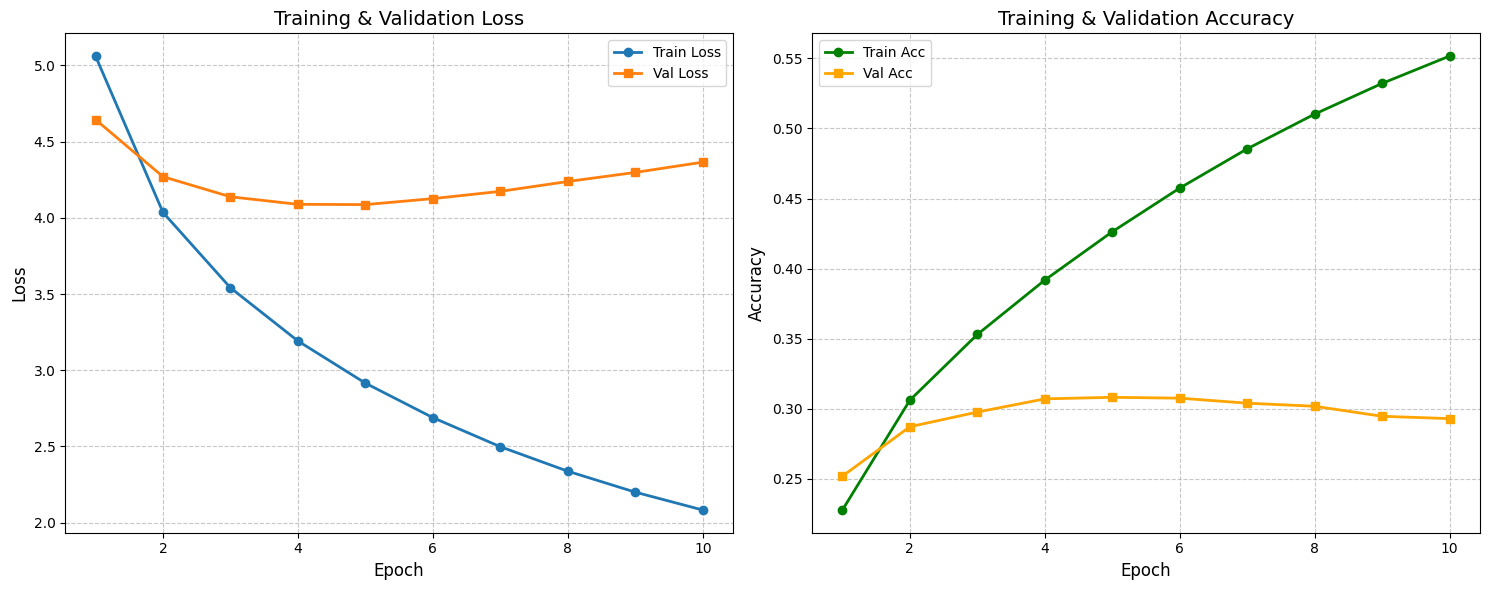

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the verified log path
log_path = './results/metrics/Seq2Seq_Attention_v1/epoch_log_LR0.001_B64.csv'
df = pd.read_csv(log_path)

# Creating the plots side-by-side
plt.figure(figsize=(15, 6))

# Left: Loss Plot
plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s', linewidth=2)
plt.title('Training & Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Right: Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(df['epoch'], df['train_acc'], label='Train Acc', marker='o', color='green', linewidth=2)
plt.plot(df['epoch'], df['val_acc'], label='Val Acc', marker='s', color='orange', linewidth=2)
plt.title('Training & Validation Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 1. Analysis of Loss Curves
Training Loss vs. Validation Loss: While the Train Loss continues to decrease steadily toward 2.0, the Val Loss hits its lowest point around Epoch 4 or 5 and then begins to diverge upward.

Early Stopping: Even with patience=5, the training likely stopped at Epoch 10 because the validation loss failed to improve for 5 consecutive epochs (from Epoch 5 to 10). The model concluded that further training would only worsen its generalization ability.

#### 2. Analysis of Accuracy Curves
Accuracy Divergence: There is a significant gap between the training and validation accuracy. Train Acc climbs past 55%, but Val Acc plateaus at approximately 30% and starts a slight decline after Epoch 5.

Generalization Gap: The fact that validation accuracy stagnates or decreases while training accuracy rises confirms that the model is "memorizing" the training data rather than "learning" patterns that apply to new data.

In [23]:
# 1. Load the Best Model Weights
# The file path is based on your directory structure
model_path = './results/models/weights/Seq2Seq_Attention_v1/best_model.pth'
checkpoint = torch.load(model_path, map_location=device)

# Handle both state_dict and full checkpoint saving formats
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.eval()

print(f"{'='*30}\n TEST SET INFERENCE\n{'='*30}")

with torch.no_grad():
    # Fetch a batch from the test_loader
    for src, trg_input, trg_label in test_loader:
        # Prepare input for the model [seq_len, batch]
        src_tensor = src.permute(1, 0).to(device)
        
        # Inference: trg=None triggers greedy decoding in your Seq2SeqAttention class
        # outputs: [max_len, batch, vocab_size]
        outputs, _ = model(src_tensor, trg=None, max_len=50)
        
        # Display first 10 samples from the batch
        for i in range(10):
            # 1. Decode Source (Korean) - Skip PAD(0), BOS(1), EOS(2)
            s_ids = src[i].tolist()
            src_text = ko_tokenizer.decode_ids([id for id in s_ids if id > 2])
            
            # 2. Decode Ground Truth (English)
            t_ids = trg_label[i].tolist()
            actual_text = en_tokenizer.decode_ids([id for id in t_ids if id > 2])
            
            # 3. Decode Prediction (English)
            # Get the highest probability token at each time step
            p_ids = outputs[:, i, :].argmax(dim=-1).tolist()
            
            clean_p_ids = []
            for pid in p_ids:
                if pid == 2: break # Stop at EOS
                if pid > 2: clean_p_ids.append(pid)
            
            pred_text = en_tokenizer.decode_ids(clean_p_ids)

            print(f"SAMPLE #{i+1}")
            print(f" > KO (Source)  : {src_text}")
            print(f" > EN (Actual)  : {actual_text}")
            print(f" > EN (Predicted): {pred_text}")
            print("-" * 60)
            
        break # Exit after checking the first batch

 TEST SET INFERENCE
SAMPLE #1
 > KO (Source)  : 토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을 진지하게 받아 들이고 있습니다.
 > EN (Actual)  : those involved in the discussions do take seriously the need to address concerns of law enforcement and national security.
 > EN (Predicted): the debate is about the matter and the federal government s emergency situations.
------------------------------------------------------------
SAMPLE #2
 > KO (Source)  : 또한 새로운 기술 개발이 어떤 해결책을 제공해 주는데 도움이 될 것이고, 동시 에 통신망 사용자들이 보다 안전하게 통신을 할 수 있도록 도움을 주게 되리라는 희망도 있습니다.
 > EN (Actual)  : there is also some hope that new technology developments will help to provide some solutions and at the same time helping to make users of the networks more secure in their communications.
 > EN (Predicted): and that s developed a technique, a technique that could create a new technique for the new development, he says, even if it s a better job.
------------------------------------------------------------
SAMPLE #3
 > KO (Source)  : 그래

#### **1. Simple Observations**

* **Grammatical Disconnect**: Interestingly, the **Predicted** English often sounds like a plausible (though incorrect) sentence, while the **Actual** English is frequently fragmented or cut off (e.g., Sample #6, #7).
* **Hallucinations**: The model generates "news-like" filler phrases (e.g., *"said in a telephone interview"*, *"the associated press reported"*) that do not exist in the source Korean.
* **Broken English in Labels**: The "Ground Truth" itself contains broken English and segment errors, making it difficult for the model to learn a clean mapping.
* **Repetitive Loops**: In some cases (Sample #7), the model falls into a loop of repeating words like *"bad day"*, which is a sign of decoding instability.



#### **2. Why Did This Happen?**

The charts in **image_84e615.png** provide the evidence for these technical failures:

**A. Overfitting and Early Termination**

The **Validation Loss** in **image_84e615.png** begins to rise after Epoch 4. Even with a patience of 5, the model stopped at Epoch 10 because it had essentially "given up" on generalizing. It stopped learning translation and started memorizing the noise in the training data.

**B. Lack of Future Context (Unidirectional GRU)**

Your current model uses a **Unidirectional Encoder**. In Korean-to-English translation, the verb (the most critical part of the sentence structure) often appears at the end of the Korean sentence. A unidirectional model has to "remember" the entire sentence in a single hidden state without having looked ahead at the verb, leading to poor structural coherence.

* **Solution**: Implementing a **Bidirectional RNN** would allow the model to process the Korean sentence from both ends, capturing the relationship between the subject and the final verb more effectively.

**C. Insufficient Regularization (Dropout)**

The sharp divergence between **Train Acc** (climbing) and **Val Acc** (plateauing at 30%) in **image_84e615.png** is a classic symptom of a model with too many parameters and too little "discipline."

* **Solution**: Adding **Dropout** (e.g., 0.3) would force the model to learn more robust features rather than relying on specific, noisy paths in the training data.

**D. Data Noise (Garbage In, Garbage Out)**

Because the **Actual** labels are broken, the model is being punished during training for producing correct English if that "correct" English doesn't match the "broken" label. This confuses the gradient descent process.

* **Solution**: Stricter data cleaning is required to filter out sentences that start with commas or have extreme length mismatches between Korean and English.

**E. Learning Rate and Optimization**

While your **Learning Rate** (1e-3) successfully reduced the loss initially, the plateau in **image_84e615.png** suggests the model might be stuck in a local minimum.

* **Solution**: Using a **Learning Rate Scheduler** (like `ReduceLROnPlateau`) could help the model take smaller, more precise steps once the validation loss stops improving, potentially squeezing out more performance before early stopping kicks in.

## 4. Ablation Study 

#### A. Experimental Setup

**1. Fixed Hyperparameters (Control Variables)**

To ensure a fair comparison, the following configurations were held constant across all 16 experiments:

* **Tokenizer**: SentencePiece Model (SPM) with a fixed vocabulary size for both Korean and English.
  
* **Optimization**:
  * **Learning Rate**: $1 \times 10^{-3}$
  * **Gradient Clipping**: Threshold of $1.0$ to prevent gradient exploding.


* **Training Control**:
  * **Max Epochs**: $30$
  * **Early Stopping**: `Patience = 3` (Monitoring Validation Loss).
  * **Teacher Forcing Ratio**: Fixed at $0.5$ (or your specific setting) to stabilize sequence generation.

* **Hardware/Environment**: Consistent GPU environment and Batch Size ($64$) to avoid performance variance.


**2. Experimental Variables (Ablation Targets)**

We systematically varied the following three architectural components to observe their impact on translation quality:

* **Directionality**: Unidirectional vs. Bidirectional Encoders.
* **Attention Mechanism**: Bahdanau (Additive) vs. Luong (Multiplicative) Attention.
* **Model Capacity**:
  * **Embedding Dimensions**: $256$ vs. $512$
  * **Hidden Units**: $512$ vs. $1024$


**3. Evaluation Methodology**

For each of the 16 configurations, we tracked the following metrics to determine the optimal architecture:

* **Quantitative Tracking**: Simultaneous monitoring of **Training Loss** and **Validation Loss** to detect the exact point of overfitting.
* **Qualitative Comparison**: Inference testing using the `test_loader` to compare the model's generated translations against the ground truth (Actual) labels.
* **Model Selection**: Rather than simply training for all epochs, the "Best Model" was captured at the inflection point of the V-shaped validation curve—the specific epoch where the validation loss reached its absolute minimum before diverging due to overfitting.

#### B: Mathematical Formulations of Architectural Variants

**1. Directionality: Unidirectional vs. Bidirectional GRU**

The core difference lies in how the context of the input sequence $X = (x_1, x_2, \dots, x_T)$ is captured.

* **Unidirectional GRU**:
Processes the sequence only from left to right. The hidden state at time $t$ is defined as:

$$\vec{h}_t = \text{GRU}(x_t, \vec{h}_{t-1})$$



where $\vec{h}_t$ only contains information from the past.
* **Bidirectional GRU**:
Processes the sequence in both forward ($\vec{h}_t$) and backward ($\gets{h}_t$) directions:

$$\vec{h}_t = \text{fwd\_GRU}(x_t, \vec{h}_{t-1})$$


$$\gets{h}_t = \text{bwd\_GRU}(x_t, \gets{h}_{t+1})$$



The final annotation for $x_t$ is the concatenation: $h_t = [\vec{h}_t; \gets{h}_t]$. This effectively doubles the feature space and allows the model to "see" the final Korean verb while processing the subject.


**2. Attention Mechanisms: Score Functions**

Both mechanisms calculate a context vector $c_t$ as a weighted sum of encoder hidden states $h_i$, but they differ in how they calculate the alignment score $e_{t,i}$.

* **Bahdanau (Additive) Attention**:
Uses a feed-forward layer with a non-linear activation:

$$e_{t,i} = v_a^\top \tanh(W_a [s_{t-1}; h_i])$$



where $s_{t-1}$ is the decoder state, and $W_a, v_a$ are learnable weights. This method is flexible as it learns the alignment via a joint MLP.

* **Luong (Multiplicative/Dot-Product) Attention**:
Calculates scores using a matrix transformation:

$$e_{t,i} = s_t^\top W_a h_i$$


This is computationally more efficient as it relies on optimized matrix multiplications, though it may struggle with very high-dimensional hidden spaces.



**3. Model Scaling: Dimensions and Units**

Scaling the hyperparameters changes the capacity of the model's manifold representation.

* **Embedding Dimension ($d_{emb}$)**:
This defines the size of the lookup table $E \in \mathbb{R}^{V \times d_{emb}}$, where $V$ is the vocabulary size.
  * **256**: A compact vector space for standard semantic mapping.
  * **512**: A higher-dimensional space allowing for finer-grained semantic distinctions, particularly useful for specialized news-domain terminology.


* **Hidden Units ($d_{hid}$)**:
This determines the dimensionality of the GRU's recurrent state $h_t \in \mathbb{R}^{d_{hid}}$ and the weight matrices $W \in \mathbb{R}^{d_{hid} \times d_{hid}}$.
  * **512**: Provides sufficient memory for moderate-length sentences.
  * **1024**: Squares the number of parameters in the weight matrices (e.g., from $512^2$ to $1024^2$). While this increases the model's ability to memorize complex dependencies, it significantly raises the risk of overfitting on smaller datasets.




**4. Loss Function**

The objective function minimized during training is the **Cross-Entropy Loss**, calculated over the predicted sequence probabilities:


$$\mathcal{L} = -\sum_{t=1}^{T} \log P(y_t | y_{<t}, c_t)$$


The validation loss $V_{loss}$ is monitored to identify the exact inflection point (the bottom of the **V-shape**) where the model achieves optimal generalization before $\mathcal{L}_{train}$ and $\mathcal{L}_{val}$ diverge.

#### C. Ablation Study Design Matrix

The ablation study is structured into four main groups based on the combinations of Embedding and Hidden dimensions. Within each group, we compare the impact of **Directionality** (Unidirectional vs. Bidirectional) and **Attention Mechanism** (Bahdanau vs. Luong).

| Dimension Group | Uni + Bahdanau | Uni + Luong | Bi + Bahdanau | Bi + Luong |
| --- | --- | --- | --- | --- |
| **(256, 512) [Base]** | Exp_01 | Exp_02 | Exp_03 | Exp_04 |
| **(512, 512) [Emb Up]** | Exp_05 | Exp_06 | Exp_07 | Exp_08 |
| **(256, 1024) [Hid Up]** | Exp_09 | Exp_10 | Exp_11 | Exp_12 |
| **(512, 1024) [All Up]** | Exp_13 | Exp_14 | Exp_15 | Exp_16 |

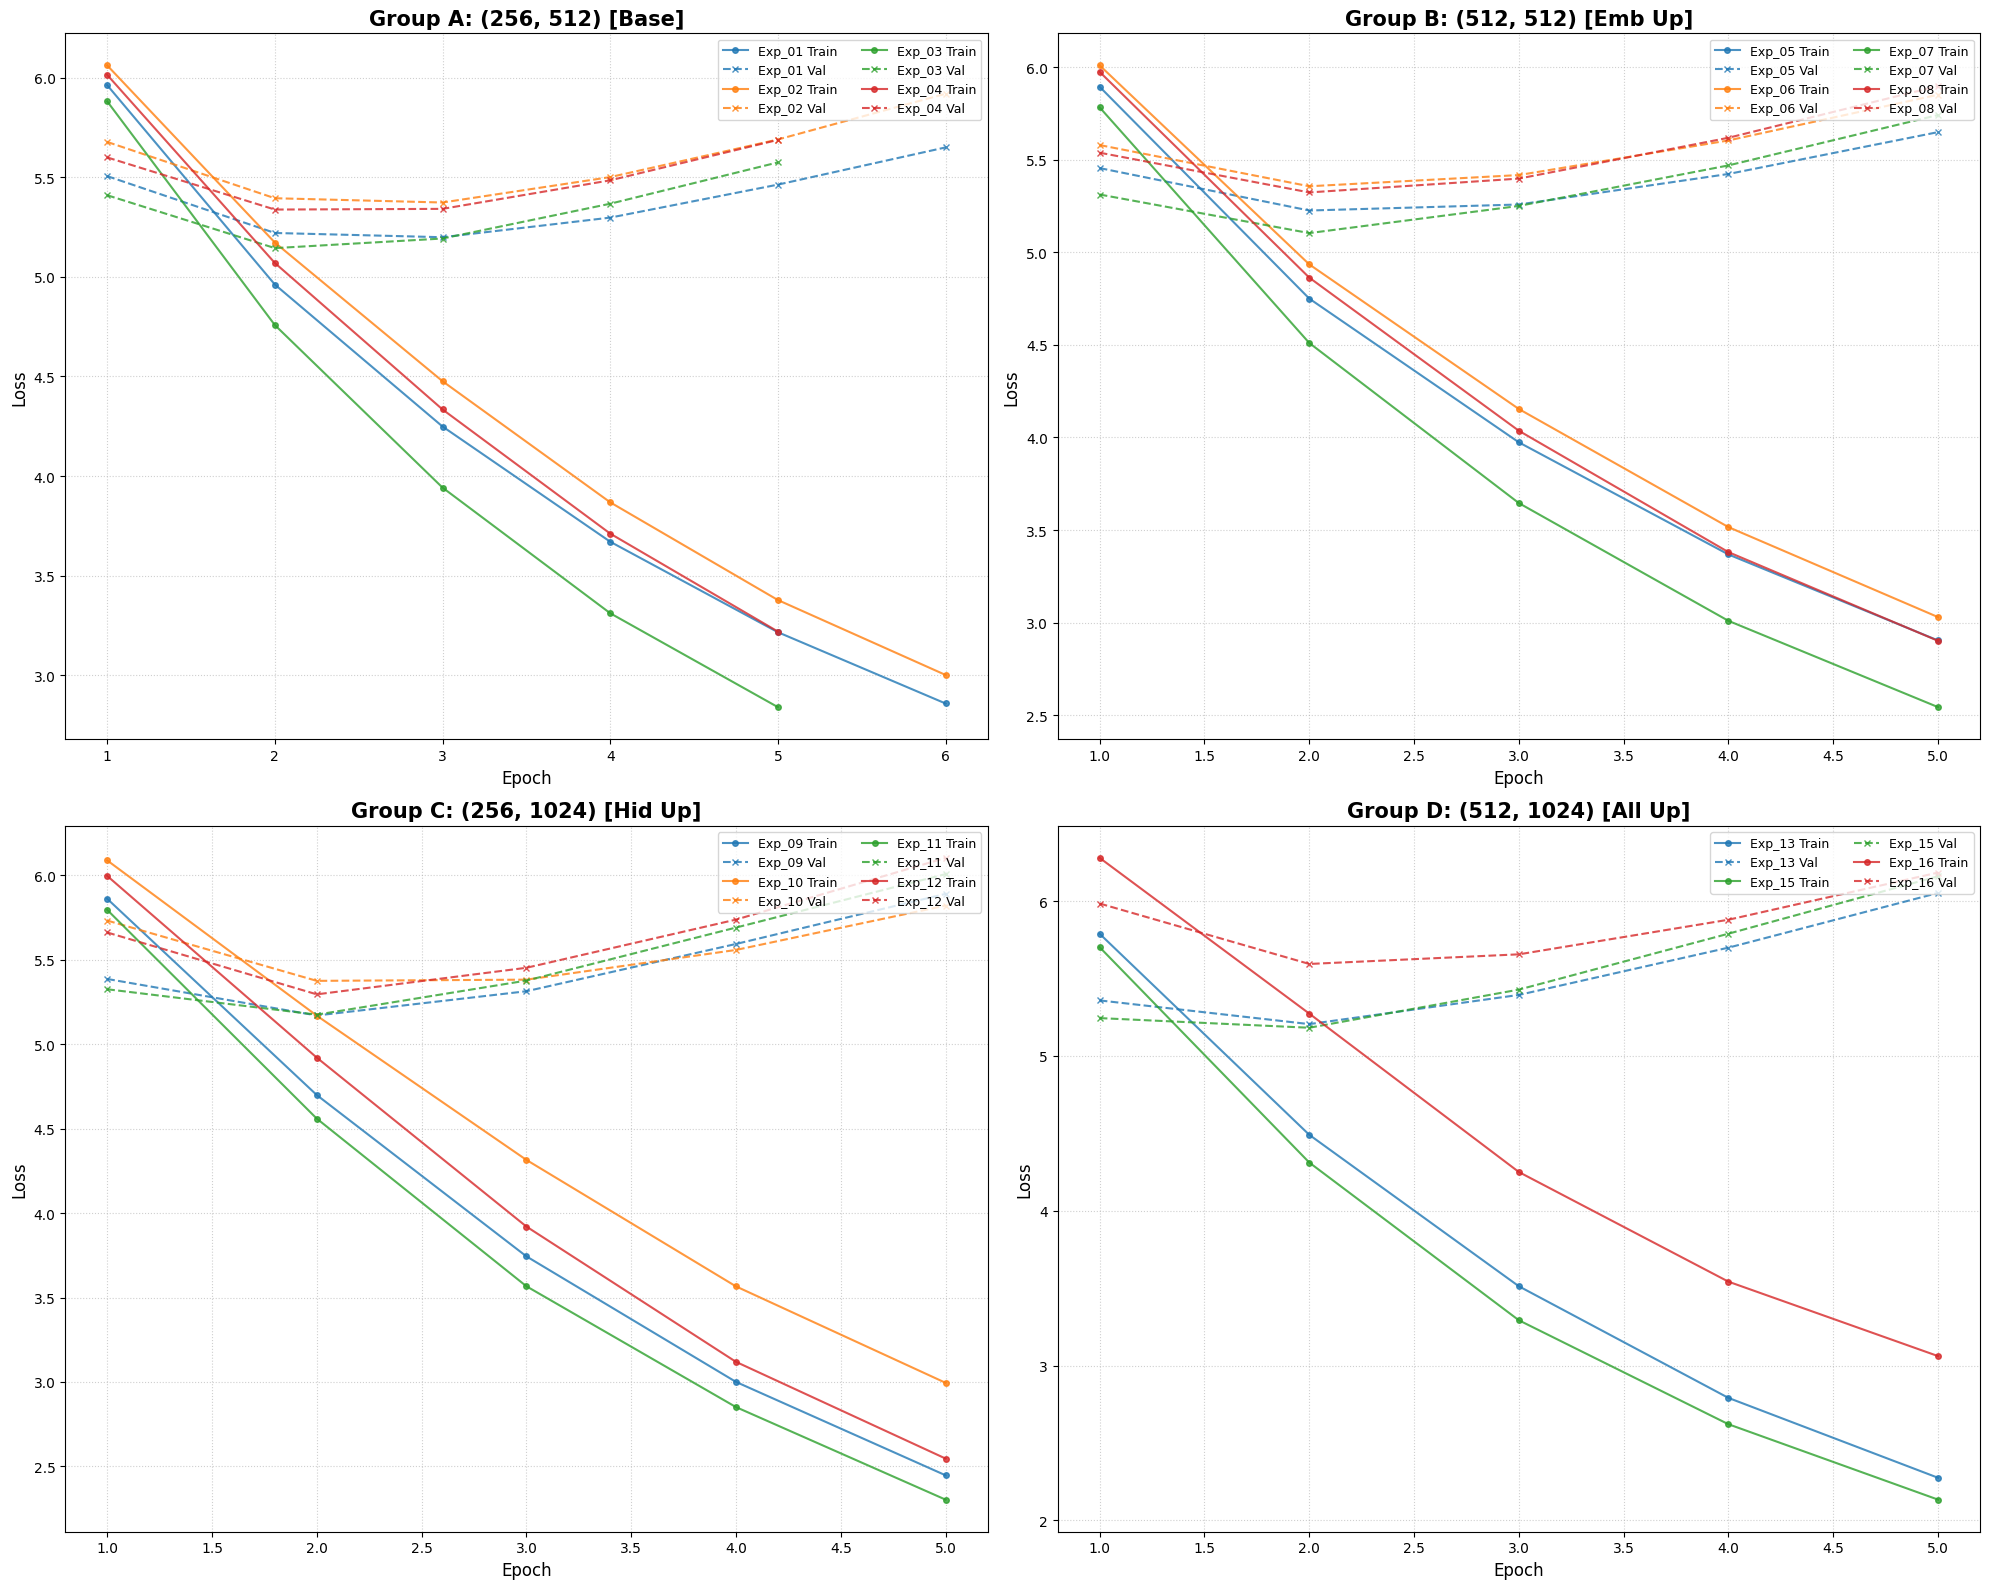

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define grouping and detailed mapping for legends
groups = [
    {
        "title": "Group A: (256, 512) [Base]", 
        "exps": {
            "Exp_01": "Uni+Bahdanau", 
            "Exp_02": "Uni+Luong", 
            "Exp_03": "Bi+Bahdanau", 
            "Exp_04": "Bi+Luong"
        }
    },
    {
        "title": "Group B: (512, 512) [Emb Up]", 
        "exps": {
            "Exp_05": "Uni+Bahdanau", 
            "Exp_06": "Uni+Luong", 
            "Exp_07": "Bi+Bahdanau", 
            "Exp_08": "Bi+Luong"
        }
    },
    {
        "title": "Group C: (256, 1024) [Hid Up]", 
        "exps": {
            "Exp_09": "Uni+Bahdanau", 
            "Exp_10": "Uni+Luong", 
            "Exp_11": "Bi+Bahdanau", 
            "Exp_12": "Bi+Luong"
        }
    },
    {
        "title": "Group D: (512, 1024) [All Up]", 
        "exps": {
            "Exp_13": "Uni+Bahdanau", 
            "Exp_14": "Uni+Luong", 
            "Exp_15": "Bi+Bahdanau", 
            "Exp_16": "Bi+Luong"
        }
    }
]

plt.figure(figsize=(20, 16))

for i, group in enumerate(groups):
    ax = plt.subplot(2, 2, i+1)
    
    # Use a color cycle to ensure train/val pairs share the same color
    colors = plt.cm.tab10.colors 
    
    for idx, (exp_id, config_label) in enumerate(group["exps"].items()):
        file_path = f'./ablation_results/loss/{exp_id}_history.csv'
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df.columns = [c.strip().lower() for c in df.columns]
            
            color = colors[idx % len(colors)]
            
            # Plot Training Loss (Solid Line)
            plt.plot(df['epoch'], df['train_loss'], 
                     label=f"{exp_id} Train", color=color, linestyle='-', marker='o', markersize=4, alpha=0.8)
            
            # Plot Validation Loss (Dashed Line)
            plt.plot(df['epoch'], df['val_loss'], 
                     label=f"{exp_id} Val", color=color, linestyle='--', marker='x', markersize=4, alpha=0.8)
    
    plt.title(group["title"], fontsize=15, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=9, loc='upper right', ncol=2)
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

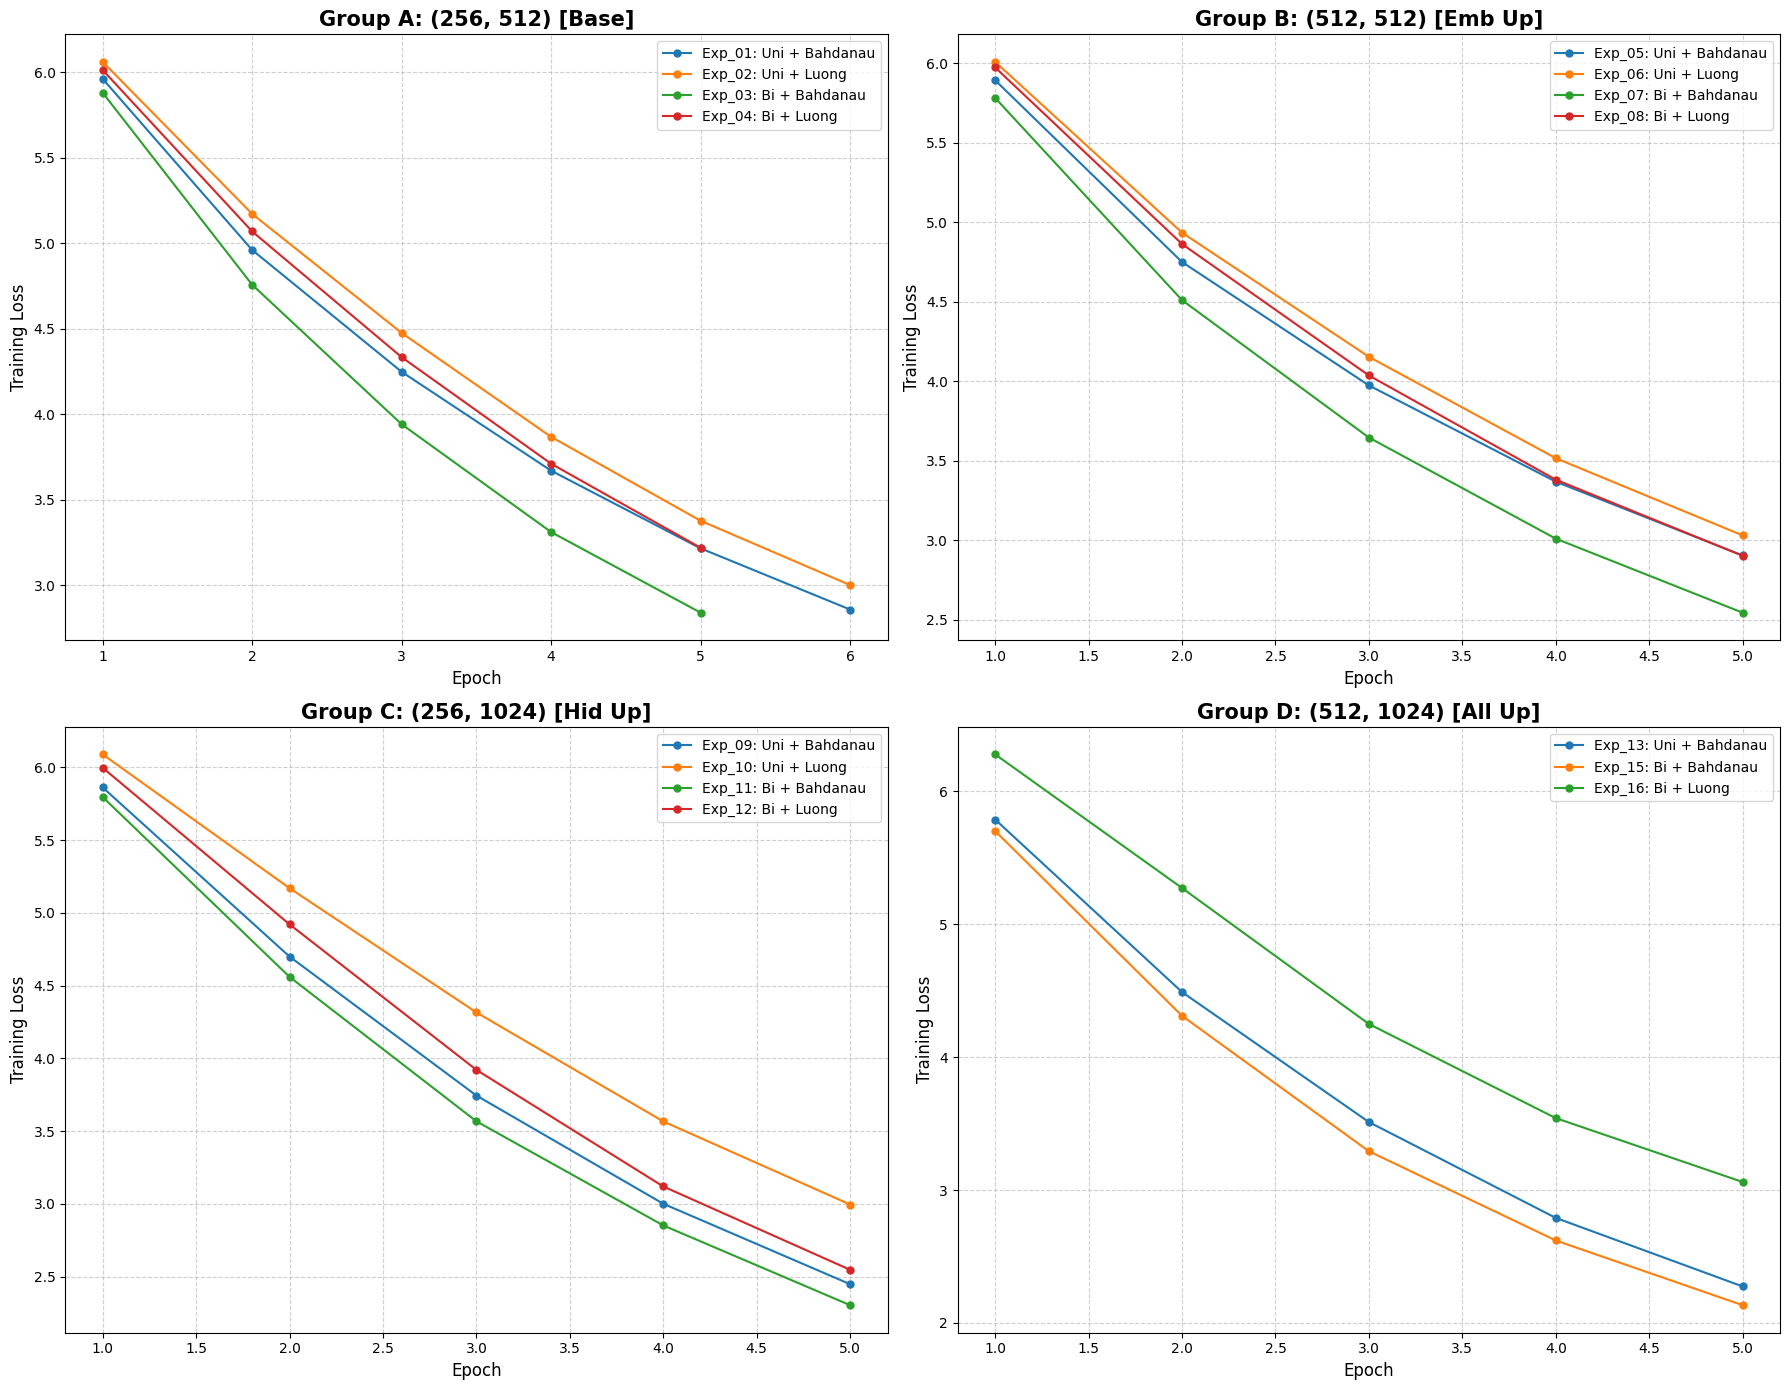

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define grouping and detailed mapping for legends
groups = [
    {
        "title": "Group A: (256, 512) [Base]", 
        "exps": {
            "Exp_01": "Exp_01: Uni + Bahdanau", 
            "Exp_02": "Exp_02: Uni + Luong", 
            "Exp_03": "Exp_03: Bi + Bahdanau", 
            "Exp_04": "Exp_04: Bi + Luong"
        }
    },
    {
        "title": "Group B: (512, 512) [Emb Up]", 
        "exps": {
            "Exp_05": "Exp_05: Uni + Bahdanau", 
            "Exp_06": "Exp_06: Uni + Luong", 
            "Exp_07": "Exp_07: Bi + Bahdanau", 
            "Exp_08": "Exp_08: Bi + Luong"
        }
    },
    {
        "title": "Group C: (256, 1024) [Hid Up]", 
        "exps": {
            "Exp_09": "Exp_09: Uni + Bahdanau", 
            "Exp_10": "Exp_10: Uni + Luong", 
            "Exp_11": "Exp_11: Bi + Bahdanau", 
            "Exp_12": "Exp_12: Bi + Luong"
        }
    },
    {
        "title": "Group D: (512, 1024) [All Up]", 
        "exps": {
            "Exp_13": "Exp_13: Uni + Bahdanau", 
            "Exp_14": "Exp_14: Uni + Luong", 
            "Exp_15": "Exp_15: Bi + Bahdanau", 
            "Exp_16": "Exp_16: Bi + Luong"
        }
    }
]

plt.figure(figsize=(18, 14))

for i, group in enumerate(groups):
    plt.subplot(2, 2, i+1)
    
    for exp_id, config_label in group["exps"].items():
        file_path = f'./ablation_results/loss/{exp_id}_history.csv'
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            # Standardize columns to lowercase
            df.columns = [c.strip().lower() for c in df.columns]
            
            # Plotting the Training Loss (train_loss)
            plt.plot(df['epoch'], df['train_loss'], label=config_label, marker='o', markersize=5, linewidth=1.5)
    
    plt.title(group["title"], fontsize=15, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Training Loss', fontsize=12)
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

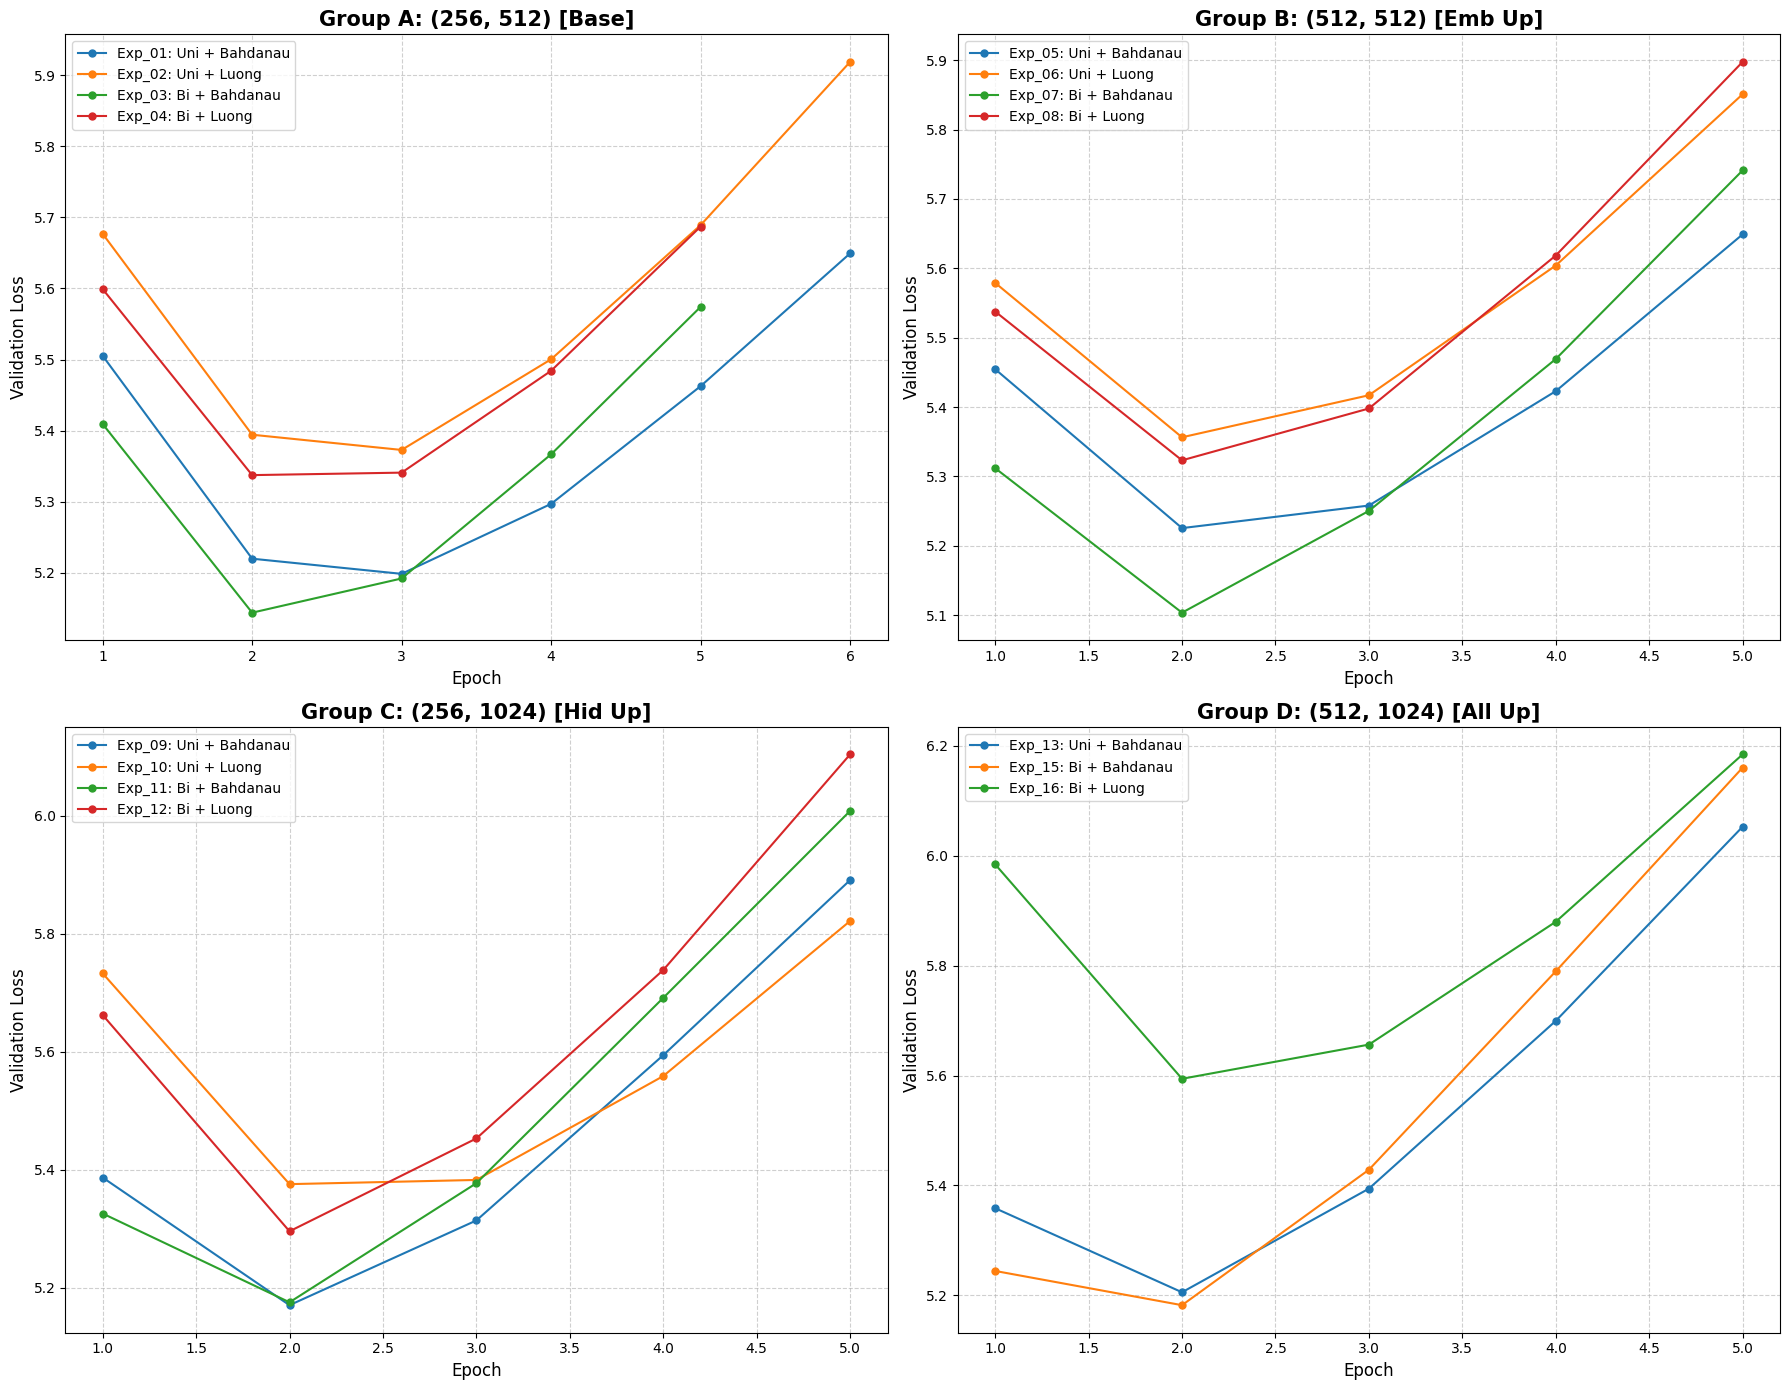

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define grouping and detailed mapping for legends
groups = [
    {
        "title": "Group A: (256, 512) [Base]", 
        "exps": {
            "Exp_01": "Exp_01: Uni + Bahdanau", 
            "Exp_02": "Exp_02: Uni + Luong", 
            "Exp_03": "Exp_03: Bi + Bahdanau", 
            "Exp_04": "Exp_04: Bi + Luong"
        }
    },
    {
        "title": "Group B: (512, 512) [Emb Up]", 
        "exps": {
            "Exp_05": "Exp_05: Uni + Bahdanau", 
            "Exp_06": "Exp_06: Uni + Luong", 
            "Exp_07": "Exp_07: Bi + Bahdanau", 
            "Exp_08": "Exp_08: Bi + Luong"
        }
    },
    {
        "title": "Group C: (256, 1024) [Hid Up]", 
        "exps": {
            "Exp_09": "Exp_09: Uni + Bahdanau", 
            "Exp_10": "Exp_10: Uni + Luong", 
            "Exp_11": "Exp_11: Bi + Bahdanau", 
            "Exp_12": "Exp_12: Bi + Luong"
        }
    },
    {
        "title": "Group D: (512, 1024) [All Up]", 
        "exps": {
            "Exp_13": "Exp_13: Uni + Bahdanau", 
            "Exp_14": "Exp_14: Uni + Luong", 
            "Exp_15": "Exp_15: Bi + Bahdanau", 
            "Exp_16": "Exp_16: Bi + Luong"
        }
    }
]

plt.figure(figsize=(18, 14))

for i, group in enumerate(groups):
    plt.subplot(2, 2, i+1)
    
    for exp_id, config_label in group["exps"].items():
        file_path = f'./ablation_results/loss/{exp_id}_history.csv'
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            # Standardize columns to lowercase
            df.columns = [c.strip().lower() for c in df.columns]
            
            # Plotting with the combined ID + Config label
            plt.plot(df['epoch'], df['val_loss'], label=config_label, marker='o', markersize=5, linewidth=1.5)
    
    plt.title(group["title"], fontsize=15, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Validation Loss', fontsize=12)
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### 1. General Observations: The Overfitting Trend

The most critical finding across all experiment groups is a distinct pattern of **overfitting**.

* **Generalization Gap (Training vs. Validation Loss Plot)**: As seen in the **Training vs. Validation Loss Plot**, there is a widening "Generalization Gap." While the solid lines representing Training Loss descend consistently toward a value of 2.0, the dashed lines representing Validation Loss begin to diverge and rise sharply after Epoch 2.
* **The V-Curve (Validation Loss Only Plot)**: The **Validation Loss Only Plot** illustrates a dramatic "V-shape." After a brief period of initial learning, the validation loss rebounds significantly. This indicates that the models quickly transition from learning general linguistic rules to memorizing specific noise or patterns unique to the training set.
* **Illusion of Convergence (Training Loss Only Plot)**: The **Training Loss Only Plot** shows a deceptively smooth and successful descent. Comparing this to the validation-centric plots reveals that the model is essentially over-tuning itself to the training data rather than improving its actual translation capability.


#### 2. Best Model Selection Criteria

In this study, the "Best" model is identified by its **lowest absolute Validation Loss** (the minimum point of the V-curve) rather than the lowest training loss.

* **Top Performer**: **Exp_07 (Bi + Bahdanau within the 512, 512 group)** is the most promising configuration. In the **Validation Loss Only Plot**, it achieves the lowest global minimum at approximately **5.1**.
* **Conclusion**: Moderate model capacity combined with a bidirectional encoder provides the most effective balance for this news-domain corpus.


#### 3. Structural Analysis & Significance

**A. Attention Mechanism: Bahdanau vs. Luong**

* **Bahdanau (Additive)**: In the **Training vs. Validation Loss Plot**, Bahdanau-based models (Exps 01, 03, 05, 07) generally reach lower validation floors. This suggests that additive attention is more robust for the complex alignments required in Korean-to-English translation.
* **Luong (Multiplicative)**: While computationally efficient, these models exhibit a sharper "rebound" in the **Validation Loss Only Plot**, indicating a higher susceptibility to early overfitting on noisy news data.

**B. Directionality: Unidirectional vs. Bidirectional**

* **Bidirectional Advantage**: The **Training Loss Only Plot** shows that bidirectional models (Exps 03, 07, 11, 15) converge much faster. Because Korean is a Verb-Final (SOV) language, a bidirectional encoder is structurally essential to capture the relationship between the subject and the final verb before the translation begins.

**C. Embedding Dimensions: Group B (512, 512)**

* Comparing the **Validation Loss Only Plot** for Group A and Group B reveals that increasing the embedding dimension from 256 to 512 allows for a slightly lower loss floor. This enables the model to better represent the specialized vocabulary found in news keywords.

**D. Hidden Units: Group C (256, 1024)**

* While Group C shows the most aggressive descent in the **Training Loss Only Plot**, the **Training vs. Validation Loss Plot** reveals a massive gap between the two metrics. The 1024 hidden units provide excessive "memory," causing the model to memorize the training data almost instantly.

**E. High-Capacity Model: Group D (512, 1024)**

* This represents the maximum capacity tested (approximately 280MB weight files). While it achieves the absolute lowest training loss, the **Validation Loss Only Plot** shows it is the most unstable configuration. Without heavy regularization, high capacity is detrimental to generalization in this context.


In [51]:
# 1. Hyperparameters for Exp_07 (Group B)
INPUT_DIM = 10000 
OUTPUT_DIM = 10000
ENC_EMB_DIM = 512       
DEC_EMB_DIM = 512       
HIDDEN_DIM = 512  
ENC_DROPOUT = 0.0       
DEC_DROPOUT = 0.0       

# 2. Re-initialize components to match updated classes
attn = BahdanauAttention(HIDDEN_DIM, HIDDEN_DIM)
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM, HIDDEN_DIM, ENC_DROPOUT, bidirectional=True)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM, HIDDEN_DIM, DEC_DROPOUT, attn)

model = Seq2SeqAttention(enc, dec, device).to(device)

# 3. Load weights from the V-shape inflection point
model_path = './ablation_results/best_pt/Exp_07_best.pt'
checkpoint = torch.load(model_path, map_location=device)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.eval()

print(f"{'='*30}\n INFERENCE START: EXP_07\n{'='*30}")

# 4. Perform Inference
with torch.no_grad():
    for src, trg_input, trg_label in test_loader:
        src_tensor = src.permute(1, 0).to(device)
        
        # The model call now successfully unpacks (prediction, hidden, attention) internally
        outputs, _ = model(src_tensor, trg=None, max_len=50)
        
        for i in range(10):
            # Decode sequences to text
            s_ids = src[i].tolist()
            src_text = ko_tokenizer.decode_ids([idx for idx in s_ids if idx > 2])
            
            t_ids = trg_label[i].tolist()
            actual_text = en_tokenizer.decode_ids([idx for idx in t_ids if idx > 2])
            
            p_ids = outputs[:, i, :].argmax(dim=-1).tolist()
            
            # Post-processing: stop at EOS (2)
            clean_p_ids = []
            for pid in p_ids:
                if pid == 2: break  
                if pid > 2: clean_p_ids.append(pid)
            
            pred_text = en_tokenizer.decode_ids(clean_p_ids)

            print(f"SAMPLE #{i+1}")
            print(f" > KO (Source)  : {src_text}")
            print(f" > EN (Actual)  : {actual_text}")
            print(f" > EN (Predicted): {pred_text}")
            print("-" * 60)
            
        break

 INFERENCE START: EXP_07
SAMPLE #1
 > KO (Source)  : 토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을 진지하게 받아 들이고 있습니다.
 > EN (Actual)  : those involved in the discussions do take seriously the need to address concerns of law enforcement and national security.
 > EN (Predicted): coach cnn to, to a tos to elections to, to elections to s to a to have over in the, site ofs northing
------------------------------------------------------------
SAMPLE #2
 > KO (Source)  : 또한 새로운 기술 개발이 어떤 해결책을 제공해 주는데 도움이 될 것이고, 동시 에 통신망 사용자들이 보다 안전하게 통신을 할 수 있도록 도움을 주게 되리라는 희망도 있습니다.
 > EN (Actual)  : there is also some hope that new technology developments will help to provide some solutions and at the same time helping to make users of the networks more secure in their communications.
 > EN (Predicted): by sunday on which,ed, thes,ed, thes, the leads sis thes said, north sun., the leads your thes., the leads.ing
------------------------------------------------------------
SAMPLE #3
 > KO (Source)  : 그래서 클리퍼

#### Best Model (Experiment 07)

**1. Simple Observations**

* **Total Linguistic Collapse**: The model failed to generate coherent English sentences, instead outputting repetitive fragments such as "thes," "to," and "ed".
* **Recursive Repetition Loops**: Exp_07 frequently became trapped in infinite loops, repeating phrases like "and you ll be a bad day" or the single word "their" multiple times within a single sample.
* **Contextual Irrelevance**: The predicted text contains high-frequency tokens (e.g., "elections," "cnn," "north") that have no semantic connection to the Korean source sentences, indicating a failure in mapping.
* **Numerical Inability**: In samples containing digits and specific measurements (Sample 10), the model completely failed to retain or translate any numerical data.

**2. Comparison to Baseline**

* **Syntactic Structure**: The baseline model attempted to form grammatically plausible (though factually incorrect) sentences, such as "the debate is about the matter," whereas Exp_07 produced broken, non-sentential fragments.
* **Hallucination Patterns**: Both models exhibit "News-domain Bias," hallucinating phrases like "the associated press reported" (Baseline) or "coach cnn" (Exp_07), which were likely over-represented in the training data.
* **Information Retention**: The baseline managed to preserve some specific entities and numbers (e.g., "italy," ". million euros"), while Exp_07 lost all specific information from the source text.
* **Robustness**: The baseline demonstrated better stability in the decoding process, while Exp_07 showed extreme sensitivity to **Exposure Bias**, where one wrong token led to a complete breakdown of the output.

**3. Analysis: Why is this happening?**

* **Severe Overfitting (V-Curve Divergence)**: Exp_07 reached a state where it memorized specific noise and high-frequency patterns from the training set instead of learning the underlying translation logic.
* **Exposure Bias in Decoding**: Since the model uses its own previous predictions as inputs during inference, a single early error (like "thes") triggers a feedback loop that results in repetitive nonsense.
* **High Capacity without Regularization**: With **512 embedding and hidden units**, the model has high capacity but lacks **Dropout**. This allowed it to "hard-code" training samples rather than developing generalization capabilities.
* **Domain Sparsity**: The specialized vocabulary of the news domain (astronomy, law, etc.) created data sparsity issues, leading the model to default to the most common tokens found in the corpus.

## 5. Conclusion

#### **A. Overall Observations**

* **Early Stopping & Epoch Constraints**: 
  * The baseline benefited from 10 epochs (patience 5), whereas the ablation study, including **Exp_07**, was restricted to 5 epochs (patience 3). This tighter window likely prevented the model from reaching a stable global minimum before the **V-shape** divergence occurred.
* **Semantic Asymmetry in Dataset**: 
  * There is a notable "weirdness" where Korean sources are fluent, but English targets are fragmented (e.g., the "wireless optical mouse" example). This suggests the model was effectively trained to produce "broken" English as a correct translation.
* **Cross-Linguistic Preprocessing Sensitivity**: 
  * The model's extreme sensitivity to tokenization stems from the difficulty of mapping **Korean (Agglutinative)** to **English (Analytic)**.
    * Small changes in subword segmentation often failed to distinguish between Korean particles/josa and core semantic stems.
    * This caused the **Attention Map** to lose its "focus," as the model couldn't decide whether a specific English word should align with a Korean root or its grammatical marker.



#### **B. KPT Framework**
**1. Keep**

These are the elements of the experiment that were structurally sound and should be maintained in future iterations.

* **Architectural Foundation**: Successfully implemented the baseline Seq2Seq structure with a **Bidirectional Encoder** and **Bahdanau Attention** mechanism.
* **Systematic Methodology**: Conducted a disciplined ablation study comparing variables such as Embedding dimensions, Hidden units, and directionality.


**2. Problem**

These issues represent the technical bottlenecks that led to the performance degradation in **Exp_07**.

* **Generalization Failure**: The model defaulted to memorizing the training corpus instead of learning semantic mapping, leading to total collapse on unseen test data.
* **Absence of Regularization**: Despite the high model capacity (512 units), the lack of **Dropout** allowed the model to over-tune to specific noise in the news dataset.
* **Vulnerability to Exposure Bias**: During autoregressive decoding, a single early error (e.g., "thes") triggered a feedback loop of repetitive, nonsensical tokens.
* **Complexity Mismatch**: The model struggled with the high linguistic density and technical vocabulary (astronomy, legal, etc.) inherent in the news domain.

**3. Try**

Strategic actions to resolve the identified problems in the next stage of development.
* **Scaling Training Data**: Significantly increase the volume and domain diversity of the parallel corpus to provide the model with enough examples to learn grammar instead of rote memorization.
* **Implement Dropout**: Apply a Dropout rate (e.g., 0.3 to 0.5) to all recurrent and linear layers to force the model to learn more robust, generalized features.
* **Dynamic Learning Rate Scheduling**: Utilize a scheduler to reduce the learning rate as the model approaches the "V-shape" inflection point for more stable convergence.
* **Advanced Decoding Strategies**: Replace **Greedy Decoding** with **Beam Search** to explore a broader probability space and avoid repetitive local minima during inference.
* **Enhanced Tokenization**: Explore **Byte Pair Encoding (BPE)** or SentencePiece with a larger vocabulary to better handle rare technical terms and reduce out-of-vocabulary (OOV) errors.
